# SkateFormer Ewaluacja PKU-MMD XSub/XView (ntu60_CSub, _j only), wariant kontrolny bez korekty mapowania kieszeni

Ten notebook odtwarza dokładnie te same runy co `PKU_Ewaluacja_XSub_XView_both_vs_baseline.ipynb` (ten sam model, te same dane, ta sama inferencja),
ale bez korekty mapowania klas 29/38 (put in pocket / take out from pocket) na wspólną klasę NTU 24.
Klasa 29 pozostaje zmapowana na NTU 56 (touch pocket) - stan sprzed korekty opisanej w pracy.

Służy jako punkt odniesienia pokazujący wpływ samej korekty mappingu kieszeni na wynik overall accuracy.
Interaction accuracy (klasy 49-57) jest identyczna jak w wersji skorygowanej, korekta dotyczy wyłącznie klasy kieszeniowej.

In [ ]:
!git clone https://github.com/KAIST-VICLab/SkateFormer.git
import os
os.chdir('/content/SkateFormer')
!ls

Cloning into 'SkateFormer'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 180 (delta 51), reused 43 (delta 35), pack-reused 102 (from 1)
Receiving objects: 100% (180/180), 1.12 MiB | 6.91 MiB/s, done.
Resolving deltas: 100% (79/79), done.
assets	data	 LICENSE  model		  README.md	     skateformer
config	feeders  main.py  pyproject.toml  requirements.yaml  torchlight


In [ ]:
!pip install -q einops==0.6.1 timm==0.9.12 tensorpack torchpack loguru msgpack msgpack-numpy tabulate tensorboardX

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.3/296.3 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil, numpy as np, os

DRIVE_DATA    = '/content/drive/MyDrive/PKU_data'
DRIVE_WEIGHTS = '/content/drive/MyDrive/SkateFormer_weights/ntu60_CSub'

os.makedirs('/content/SkateFormer/data/ntu', exist_ok=True)

npz_src = f'{DRIVE_DATA}/PKU_XSub_both.npz'
npz_dst = '/content/SkateFormer/data/ntu/PKU_XSub_both.npz'
if not os.path.exists(npz_dst):
    shutil.copy(npz_src, npz_dst)
    print('Skopiowano: PKU_XSub_both.npz')
npz_src = f'{DRIVE_DATA}/PKU_XView_both.npz'
npz_dst = '/content/SkateFormer/data/ntu/PKU_XView_both.npz'
if not os.path.exists(npz_dst):
    shutil.copy(npz_src, npz_dst)
    print('Skopiowano: PKU_XView_both.npz')
npz_src = f'{DRIVE_DATA}/PKU_XSub.npz'
npz_dst = '/content/SkateFormer/data/ntu/PKU_XSub.npz'
if not os.path.exists(npz_dst):
    shutil.copy(npz_src, npz_dst)
    print('Skopiowano: PKU_XSub.npz')
npz_src = f'{DRIVE_DATA}/PKU_XView.npz'
npz_dst = '/content/SkateFormer/data/ntu/PKU_XView.npz'
if not os.path.exists(npz_dst):
    shutil.copy(npz_src, npz_dst)
    print('Skopiowano: PKU_XView.npz')
d = np.load(npz_dst)
print(f'train: {d["x_train"].shape}  test: {d["x_test"].shape}')

pt_src = f'{DRIVE_WEIGHTS}/SkateFormer_j.pt'
pt_dst = '/content/SkateFormer/SkateFormer_j.pt'
if not os.path.exists(pt_dst):
    shutil.copy(pt_src, pt_dst)
    print(f'Skopiowano: SkateFormer_j.pt  ({os.path.getsize(pt_dst)/1024**2:.1f} MB)')
else:
    print('Wagi już istnieją lokalnie.')


Skopiowano: PKU_XSub_both.npz
Skopiowano: PKU_XView_both.npz
Skopiowano: PKU_XSub.npz
Skopiowano: PKU_XView.npz
train: (14268, 300, 150)  test: (7141, 300, 150)
Skopiowano: SkateFormer_j.pt  (13.9 MB)


In [ ]:
import os, sys
os.chdir('/content/SkateFormer')

#Poprawka torchlight
with open('/content/SkateFormer/torchlight/torchlight/__init__.py', 'w') as f:
    f.write('''import argparse

class DictAction(argparse.Action):
    def __call__(self, parser, namespace, values, option_string=None):
        input_dict = getattr(namespace, self.dest, {}) or {}
        for kv in values:
            key, val = kv.split("=", 1)
            try:
                val = eval(val)
            except:
                pass
            input_dict[key] = val
        setattr(namespace, self.dest, input_dict)

class IO:
    pass
''')
print('Zastosowano poprawkę torchlight.')

#Usunięcie konfliktu z zainstalowaną wersją torchlight
os.system('pip uninstall torchlight -y')
if 'torchlight' in sys.modules:
    del sys.modules['torchlight']
sys.path.insert(0, '/content/SkateFormer/torchlight')
print('Usunięto konflikt z systemowym torchlight.')

#Poprawka main.py
with open('/content/SkateFormer/main.py', 'r') as f:
    content = f.read()
content = content.replace(
    'from torchlight import DictAction',
    '''class DictAction(argparse.Action):
    def __call__(self, parser, namespace, values, option_string=None):
        input_dict = getattr(namespace, self.dest, {}) or {}
        for kv in values:
            key, val = kv.split("=", 1)
            try:
                val = eval(val)
            except:
                pass
            input_dict[key] = val
        setattr(namespace, self.dest, input_dict)'''
)
content = content.replace('default_arg = yaml.load(f)',
                          'default_arg = yaml.load(f, Loader=yaml.SafeLoader)')
with open('/content/SkateFormer/main.py', 'w') as f:
    f.write(content)
print('Zastosowano poprawkę main.py.')

#Zastąpienie przestarzałego np.int
with open('/content/SkateFormer/feeders/feeder_ntu.py', 'r') as f:
    content = f.read()
content = content.replace('.astype(np.int)', '.astype(int)')
with open('/content/SkateFormer/feeders/feeder_ntu.py', 'w') as f:
    f.write(content)
print('Zastąpiono przestarzały typ np.int.')

#Zastąpienie przestarzałych typów NumPy
with open('/content/SkateFormer/feeders/tools.py', 'r') as f:
    content = f.read()
for old, new in [('np.int)', 'int)'), ('np.int,', 'int,'),
                 ('np.float)', 'float)'), ('np.float,', 'float,'),
                 ('np.bool)', 'bool)'), ('np.complex)', 'complex)')]:
    content = content.replace(old, new)
with open('/content/SkateFormer/feeders/tools.py', 'w') as f:
    f.write(content)
print('Zastąpiono przestarzałe typy NumPy.')

print('\nZakończono dostosowanie kodu SkateFormer.')

Zastosowano poprawkę torchlight.
Usunięto konflikt z systemowym torchlight.
Zastosowano poprawkę main.py.
Zastąpiono przestarzały typ np.int.
Zastąpiono przestarzałe typy NumPy.

Zakończono dostosowanie kodu SkateFormer.


In [ ]:
#Run A - XSub pipline both, dane po korekcie mapowanie 29,38 to 24.
import yaml

WORK_DIR = './work_dir/ntu60_CSub/xsub/SkateFormer_j'
NPZ_PATH = './data/ntu/PKU_XSub_both.npz'
PT_PATH  = '/content/SkateFormer/SkateFormer_j.pt'

config = {
    'seed': 1,
    'num_worker': 4,
    'work_dir': WORK_DIR,
    'phase': 'test',
    'weights': PT_PATH,
    'feeder': 'feeders.feeder_ntu.Feeder',
    'train_feeder_args': {
        'data_path': NPZ_PATH, 'split': 'train', 'debug': False,
        'window_size': 64, 'p_interval': [0.5, 1], 'aug_method': 'a123489',
        'intra_p': 0.5, 'inter_p': 0.2, 'thres': 64, 'uniform': True, 'partition': True
    },
    'test_feeder_args': {
        'data_path': NPZ_PATH, 'split': 'test', 'window_size': 64,
        'p_interval': [0.95], 'thres': 64, 'uniform': True, 'partition': True, 'debug': False
    },
    'model': 'model.SkateFormer.SkateFormer_',
    'model_args': {
        'num_classes': 60, 'num_people': 2, 'num_points': 24, 'kernel_size': 7,
        'num_heads': 32, 'attn_drop': 0.5, 'head_drop': 0.0, 'rel': True,
        'drop_path': 0.2, 'type_1_size': [8, 8], 'type_2_size': [8, 12],
        'type_3_size': [8, 8], 'type_4_size': [8, 12], 'mlp_ratio': 4.0, 'index_t': True
    },
    'device': [0], 'batch_size': 128, 'test_batch_size': 128,
    'num_epoch': 1, 'save_score': True
}

os.makedirs('config/test/pku_xsub', exist_ok=True)
os.makedirs(WORK_DIR, exist_ok=True)
with open('config/test/pku_xsub/SkateFormer_j.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

!python main.py --config config/test/pku_xsub/SkateFormer_j.yaml

<function SkateFormer_ at 0x7a315c5e76a0>
/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[ Sat Sep  5 19:15:35 2026 ] Load weights from /content/SkateFormer/SkateFormer_j.pt.
[ Sat Sep  5 19:15:37 2026 ] Model:   model.SkateFormer.SkateFormer_.
[ Sat Sep  5 19:15:37 2026 ] Weights: /content/SkateFormer/SkateFormer_j.pt.
[ Sat Sep  5 19:15:37 2026 ] Eval epoch: 1
100% 22/22 [00:04<00:00,  4.49it/s]
Accuracy:  0.6261127596439169  model:  
[ Sat Sep  5 19:15:42 2026 ] 	Mean test loss of 22 batches: 1.7972419641234658.
[ Sat Sep  5 19:15:42 2026 ] 	Top1: 62.61%
[ Sat Sep  5 19:15:42 2026 ] 	Top5: 80.12%
/content/SkateFormer/main.py:450: RuntimeWarning: invalid value encountered in divide
  each_acc = list_diag / list_raw_su

Próbek: 2696
Overall Top1: 62.61%

── Per-class accuracy ──────────────────────────────────────────
PKU Akcja                 NTU idx  Correct   Total     Acc
------------------------------------------------------------
drink water                     0        8      60   13.3%
eat meal                        1        1      57    1.8%
brush teeth                     2       17      54   31.5%
brush hair                      3       28      54   51.9%
drop                            4        7      54   13.0%
pick up                         5       63      63  100.0%
throw                           6       53      54   98.1%
sit down                        7       54      60   90.0%
stand up                        8       60      60  100.0%
clapping                        9       43      57   75.4%
reading                        10        7      53   13.2%
writing                        11       21      57   36.8%
tear paper                     12        6      47   12.8%
wear jacket  

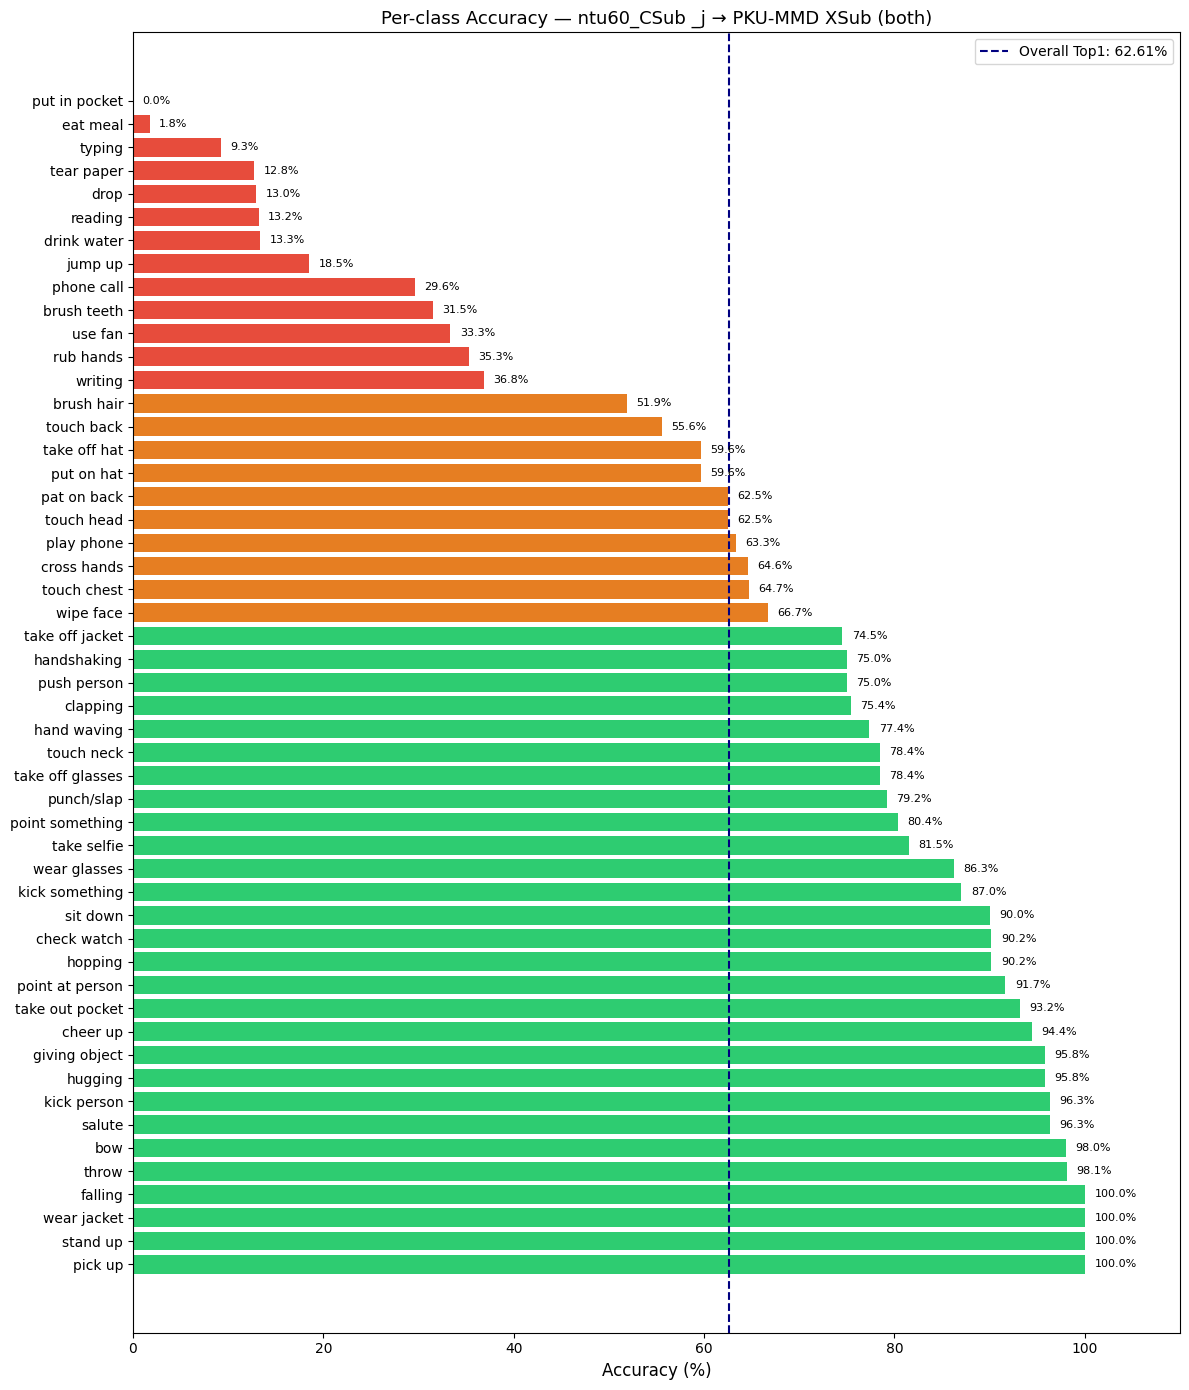

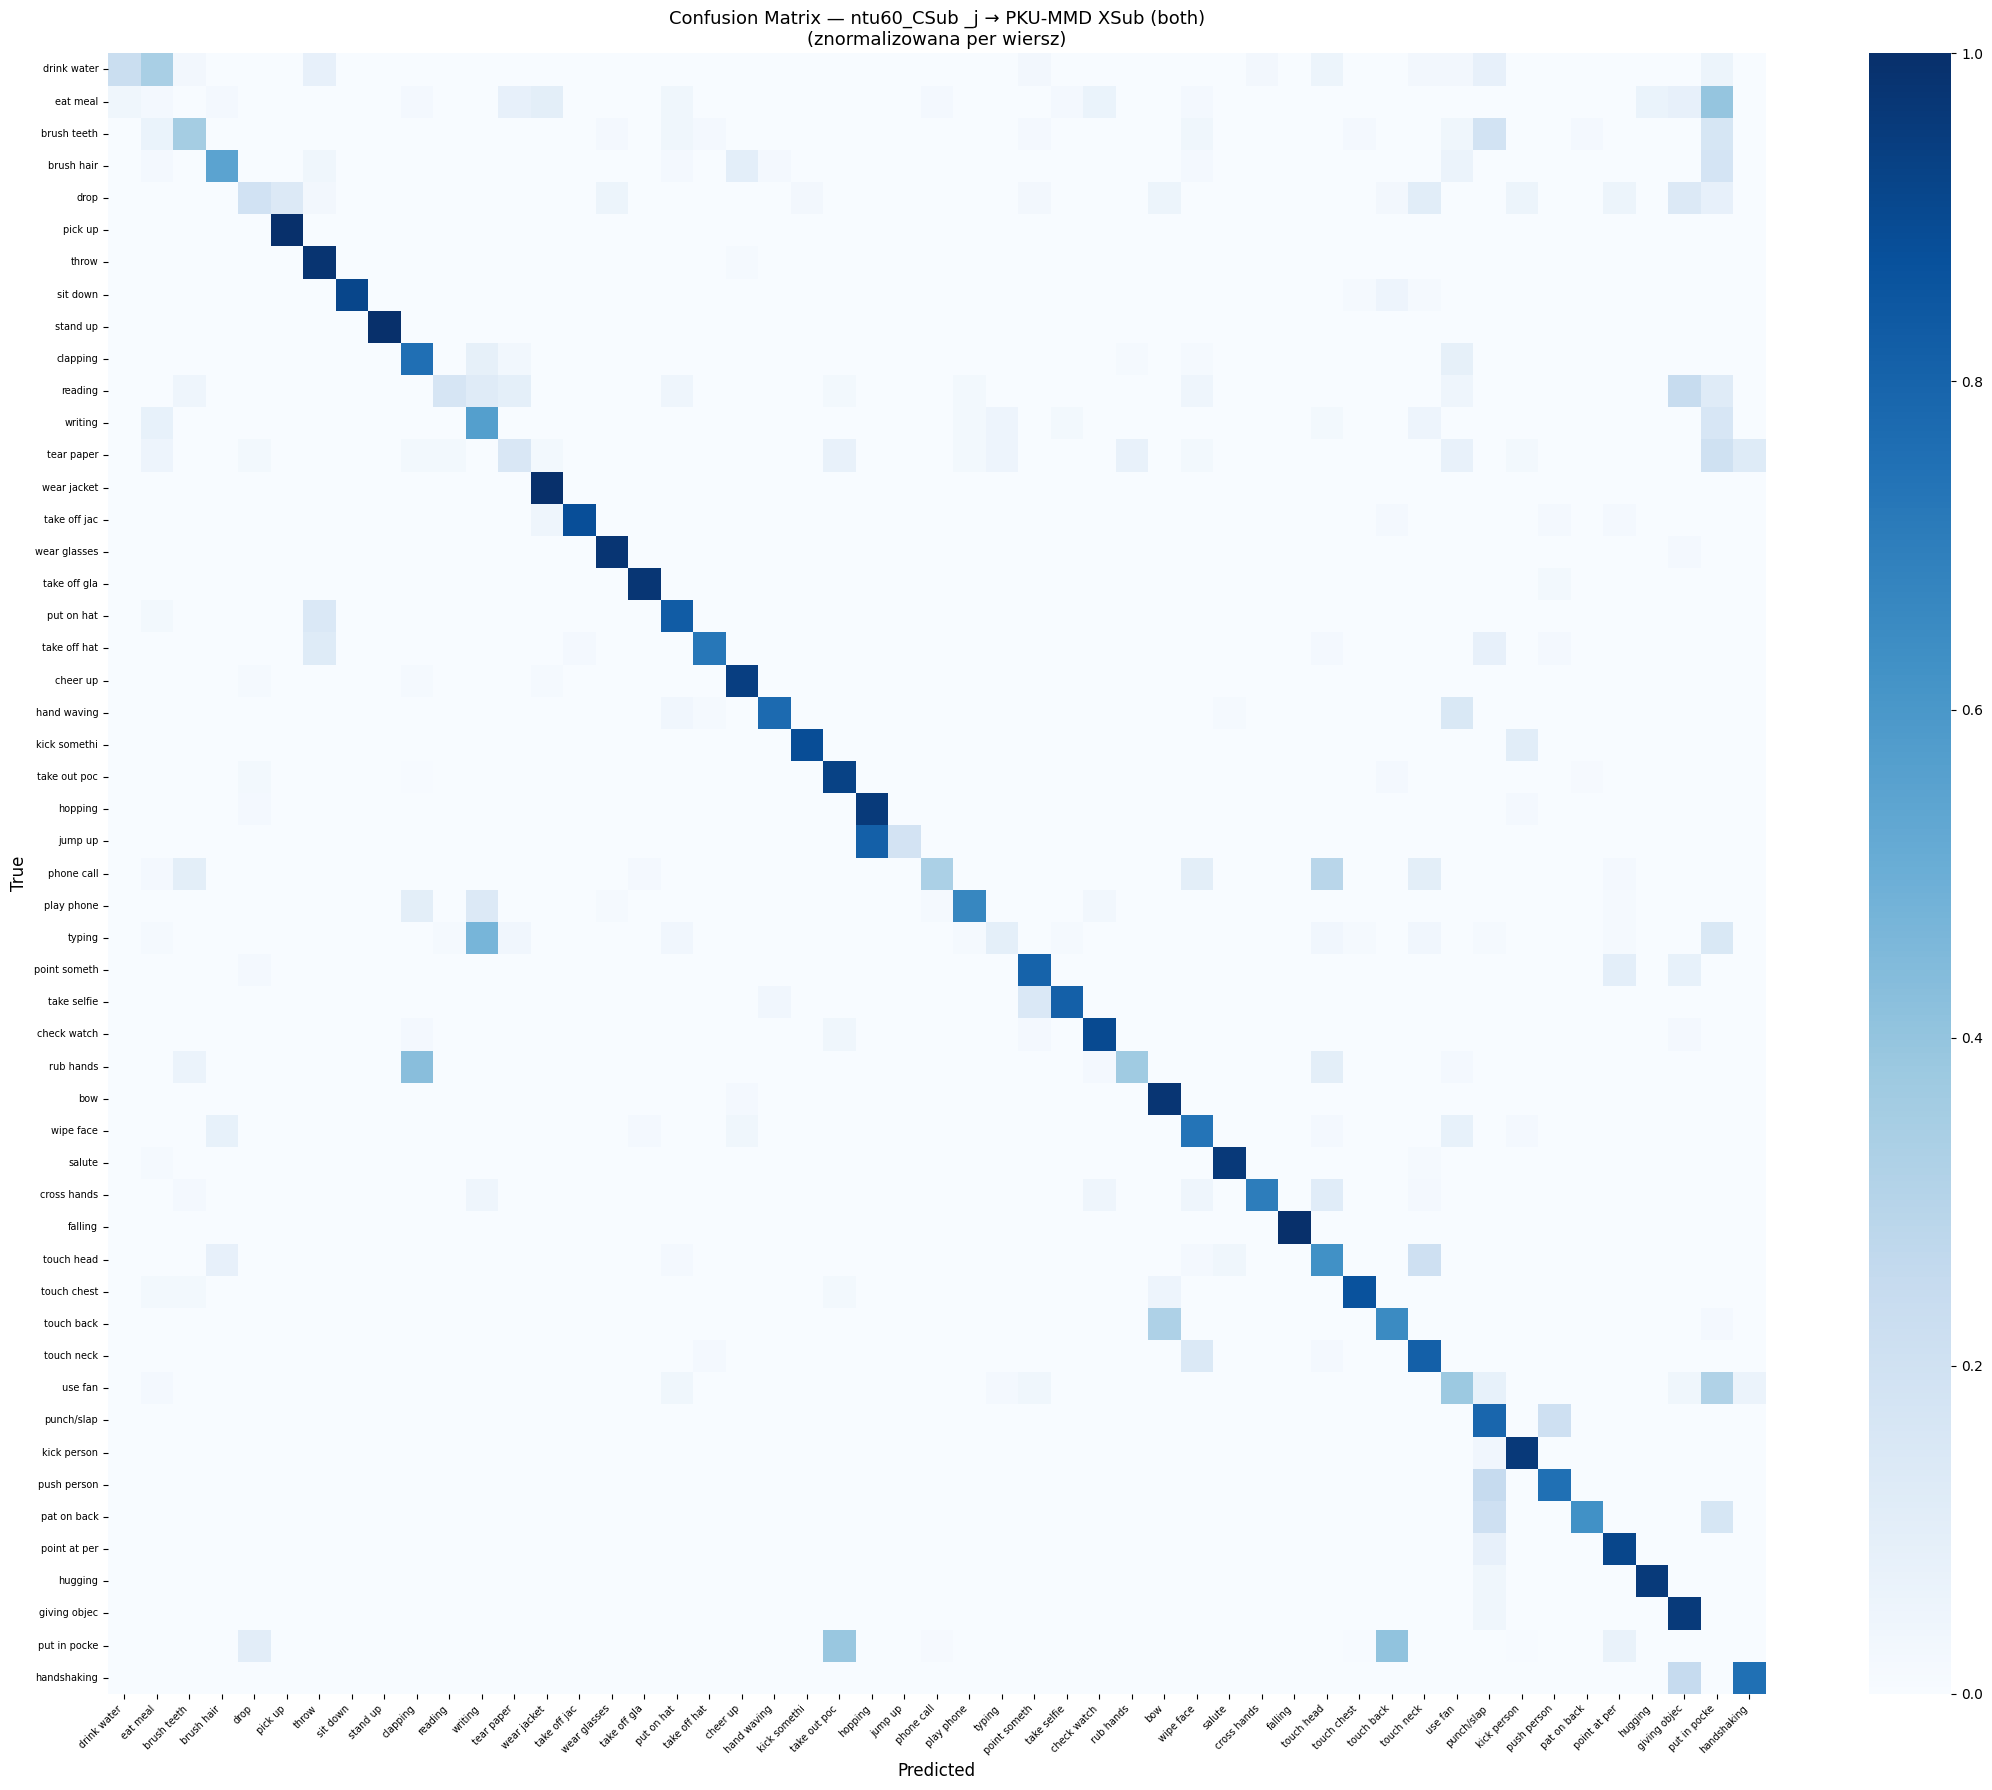

In [ ]:
import numpy as np, pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

WORK_DIR = './work_dir/ntu60_CSub/xsub/SkateFormer_j'
NPZ_PATH = './data/ntu/PKU_XSub_both.npz'

with open(f'{WORK_DIR}/epoch1_test_score.pkl', 'rb') as f:
    score_data = pickle.load(f)

data   = np.load(NPZ_PATH)
y_true = np.argmax(data['y_test'], axis=1)
keys   = sorted(score_data.keys(), key=lambda x: int(x.split('_')[1]))
scores = np.array([score_data[k] for k in keys])
y_pred = np.argmax(scores, axis=1)

print(f'Próbek: {len(y_true)}')
print(f'Overall Top1: {(y_true == y_pred).mean()*100:.2f}%')

PKU_TO_NTU = {
    1:34, 2:3, 3:2, 4:32, 5:21, 6:9, 7:39, 8:0, 9:4, 10:1,
    11:42, 12:55, 13:22, 14:57, 15:25, 16:54, 17:26, 18:50, 19:23, 20:27,
    21:52, 22:5, 23:28, 24:53, 25:30, 26:49, 27:51, 28:19, 29:56, 30:10,
    31:33, 32:37, 33:7, 34:8, 35:20, 36:18, 37:14, 38:24, 39:31, 40:12,
    41:6, 42:45, 43:44, 44:43, 45:46, 46:29, 47:48, 48:13, 49:17, 50:36, 51:11
}
PKU_NAMES = {
    1:'bow', 2:'brush hair', 3:'brush teeth', 4:'check watch', 5:'cheer up',
    6:'clapping', 7:'cross hands', 8:'drink water', 9:'drop', 10:'eat meal',
    11:'falling', 12:'giving object', 13:'hand waving', 14:'handshaking',
    15:'hopping', 16:'hugging', 17:'jump up', 18:'kick person', 19:'kick something',
    20:'phone call', 21:'pat on back', 22:'pick up', 23:'play phone',
    24:'point at person', 25:'point something', 26:'punch/slap', 27:'push person',
    28:'put on hat', 29:'put in pocket', 30:'reading', 31:'rub hands',
    32:'salute', 33:'sit down', 34:'stand up', 35:'take off hat',
    36:'take off glasses', 37:'take off jacket', 38:'take out pocket',
    39:'take selfie', 40:'tear paper', 41:'throw', 42:'touch back',
    43:'touch chest', 44:'touch head', 45:'touch neck', 46:'typing',
    47:'use fan', 48:'wear jacket', 49:'wear glasses', 50:'wipe face', 51:'writing'
}
NTU_TO_NAME = {v: PKU_NAMES[k] for k, v in PKU_TO_NTU.items()}
used_ntu    = sorted(NTU_TO_NAME.keys())

print('\n── Per-class accuracy ──────────────────────────────────────────')
print(f'{"PKU Akcja":<25} {"NTU idx":>7} {"Correct":>8} {"Total":>7} {"Acc":>7}')
print('-' * 60)
per_class = []
for ntu_idx in used_ntu:
    mask    = (y_true == ntu_idx)
    total   = mask.sum()
    if total == 0: continue
    correct = (y_pred[mask] == ntu_idx).sum()
    acc     = correct / total * 100
    per_class.append((NTU_TO_NAME[ntu_idx], ntu_idx, correct, total, acc))
    print(f'{NTU_TO_NAME[ntu_idx]:<25} {ntu_idx:>7} {correct:>8} {total:>7} {acc:>6.1f}%')

per_class_sorted = sorted(per_class, key=lambda x: x[4], reverse=True)
fig, ax = plt.subplots(figsize=(12, 14))
names  = [x[0] for x in per_class_sorted]
accs   = [x[4] for x in per_class_sorted]
colors = ['#2ecc71' if a >= 70 else '#e67e22' if a >= 40 else '#e74c3c' for a in accs]
bars   = ax.barh(names, accs, color=colors)
overall = (y_true == y_pred).mean() * 100
ax.axvline(x=overall, color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall Top1: {overall:.2f}%')
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-class Accuracy — ntu60_CSub _j → PKU-MMD XSub (both)', fontsize=13)
ax.legend()
ax.set_xlim(0, 110)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

mask_used  = np.isin(y_true, used_ntu)
y_true_cm  = y_true[mask_used]
y_pred_cm  = y_pred[mask_used]
remap      = {ntu: i for i, ntu in enumerate(used_ntu)}
y_true_r   = np.array([remap[v] for v in y_true_cm])
y_pred_r   = np.array([remap[v] if v in remap else len(used_ntu) for v in y_pred_cm])
cm         = confusion_matrix(y_true_r, y_pred_r, labels=list(range(len(used_ntu))))
cm_norm    = cm.astype(float) / cm.sum(axis=1, keepdims=True)
short_names = [NTU_TO_NAME[c][:12] for c in used_ntu]
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(cm_norm, annot=False, cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix — ntu60_CSub _j → PKU-MMD XSub (both)\n(znormalizowana per wiersz)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
INTERACTION_NTU = [49, 50, 51, 52, 53, 54, 55, 57]
INT_NAMES = {
    49: 'punch/slap', 50: 'kick person', 51: 'push person', 52: 'pat on back',
    53: 'point at person', 54: 'hugging', 55: 'giving object', 57: 'handshaking'
}

mask_int   = np.isin(y_true, INTERACTION_NTU)
y_true_int = y_true[mask_int]
y_pred_int = y_pred[mask_int]

print(f'Próbek interakcyjnych: {mask_int.sum()}')
print(f'Interaction Top1: {(y_true_int == y_pred_int).mean()*100:.2f}%')
print()
print(f'{"Akcja":<20} {"Correct":>8} {"Total":>7} {"Acc":>7}')
print('-' * 45)
for ntu_idx in sorted(INTERACTION_NTU):
    mask    = (y_true_int == ntu_idx)
    total   = mask.sum()
    if total == 0: continue
    correct = (y_pred_int[mask] == ntu_idx).sum()
    print(f'{INT_NAMES[ntu_idx]:<20} {correct:>8} {total:>7} {correct/total*100:>6.1f}%')


Próbek interakcyjnych: 195
Interaction Top1: 84.10%

Akcja                 Correct   Total     Acc
---------------------------------------------
punch/slap                 19      24   79.2%
kick person                26      27   96.3%
push person                18      24   75.0%
pat on back                15      24   62.5%
point at person            22      24   91.7%
hugging                    23      24   95.8%
giving object              23      24   95.8%
handshaking                18      24   75.0%


In [ ]:
#Run B - XView pipline both, dane po korekcie mapowanie 29,38 to 24.
import yaml

NPZ_PATH = './data/ntu/PKU_XView_both.npz'
WORK_DIR = './work_dir/ntu60_CSub/xview/SkateFormer_j'
PT_PATH  = '/content/SkateFormer/SkateFormer_j.pt'

config = {
    'seed': 1,
    'num_worker': 4,
    'work_dir': WORK_DIR,
    'phase': 'test',
    'weights': PT_PATH,
    'feeder': 'feeders.feeder_ntu.Feeder',
    'train_feeder_args': {
        'data_path': NPZ_PATH, 'split': 'train', 'debug': False,
        'window_size': 64, 'p_interval': [0.5, 1], 'aug_method': 'a123489',
        'intra_p': 0.5, 'inter_p': 0.2, 'thres': 64, 'uniform': True, 'partition': True
    },
    'test_feeder_args': {
        'data_path': NPZ_PATH, 'split': 'test', 'window_size': 64,
        'p_interval': [0.95], 'thres': 64, 'uniform': True, 'partition': True, 'debug': False
    },
    'model': 'model.SkateFormer.SkateFormer_',
    'model_args': {
        'num_classes': 60, 'num_people': 2, 'num_points': 24, 'kernel_size': 7,
        'num_heads': 32, 'attn_drop': 0.5, 'head_drop': 0.0, 'rel': True,
        'drop_path': 0.2, 'type_1_size': [8, 8], 'type_2_size': [8, 12],
        'type_3_size': [8, 8], 'type_4_size': [8, 12], 'mlp_ratio': 4.0, 'index_t': True
    },
    'device': [0], 'batch_size': 128, 'test_batch_size': 128,
    'num_epoch': 1, 'save_score': True
}

os.makedirs('config/test/pku_xsub', exist_ok=True)
os.makedirs(WORK_DIR, exist_ok=True)
with open('config/test/pku_xsub/SkateFormer_j.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

!python main.py --config config/test/pku_xsub/SkateFormer_j.yaml


<function SkateFormer_ at 0x7822f8f285e0>
/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[ Sat Sep  5 19:15:57 2026 ] Load weights from /content/SkateFormer/SkateFormer_j.pt.
[ Sat Sep  5 19:16:02 2026 ] Model:   model.SkateFormer.SkateFormer_.
[ Sat Sep  5 19:16:02 2026 ] Weights: /content/SkateFormer/SkateFormer_j.pt.
[ Sat Sep  5 19:16:02 2026 ] Eval epoch: 1
100% 56/56 [00:09<00:00,  5.69it/s]
Accuracy:  0.6279232600476123  model:  
[ Sat Sep  5 19:16:12 2026 ] 	Mean test loss of 56 batches: 1.7529489525726862.
[ Sat Sep  5 19:16:12 2026 ] 	Top1: 62.79%
[ Sat Sep  5 19:16:12 2026 ] 	Top5: 81.05%
/content/SkateFormer/main.py:450: RuntimeWarning: invalid value encountered in divide
  each_acc = list_diag / list_raw_su

Próbek: 7141
Overall Top1: 62.79%

── Per-class accuracy ──────────────────────────────────────────
PKU Akcja                 NTU idx  Correct   Total     Acc
------------------------------------------------------------
drink water                     0       13     157    8.3%
eat meal                        1       10     142    7.0%
brush teeth                     2       35     143   24.5%
brush hair                      3       83     154   53.9%
drop                            4       22     146   15.1%
pick up                         5      154     171   90.1%
throw                           6      135     137   98.5%
sit down                        7      176     184   95.7%
stand up                        8      176     183   96.2%
clapping                        9      127     145   87.6%
reading                        10       22     143   15.4%
writing                        11       71     152   46.7%
tear paper                     12       56     139   40.3%
wear jacket  

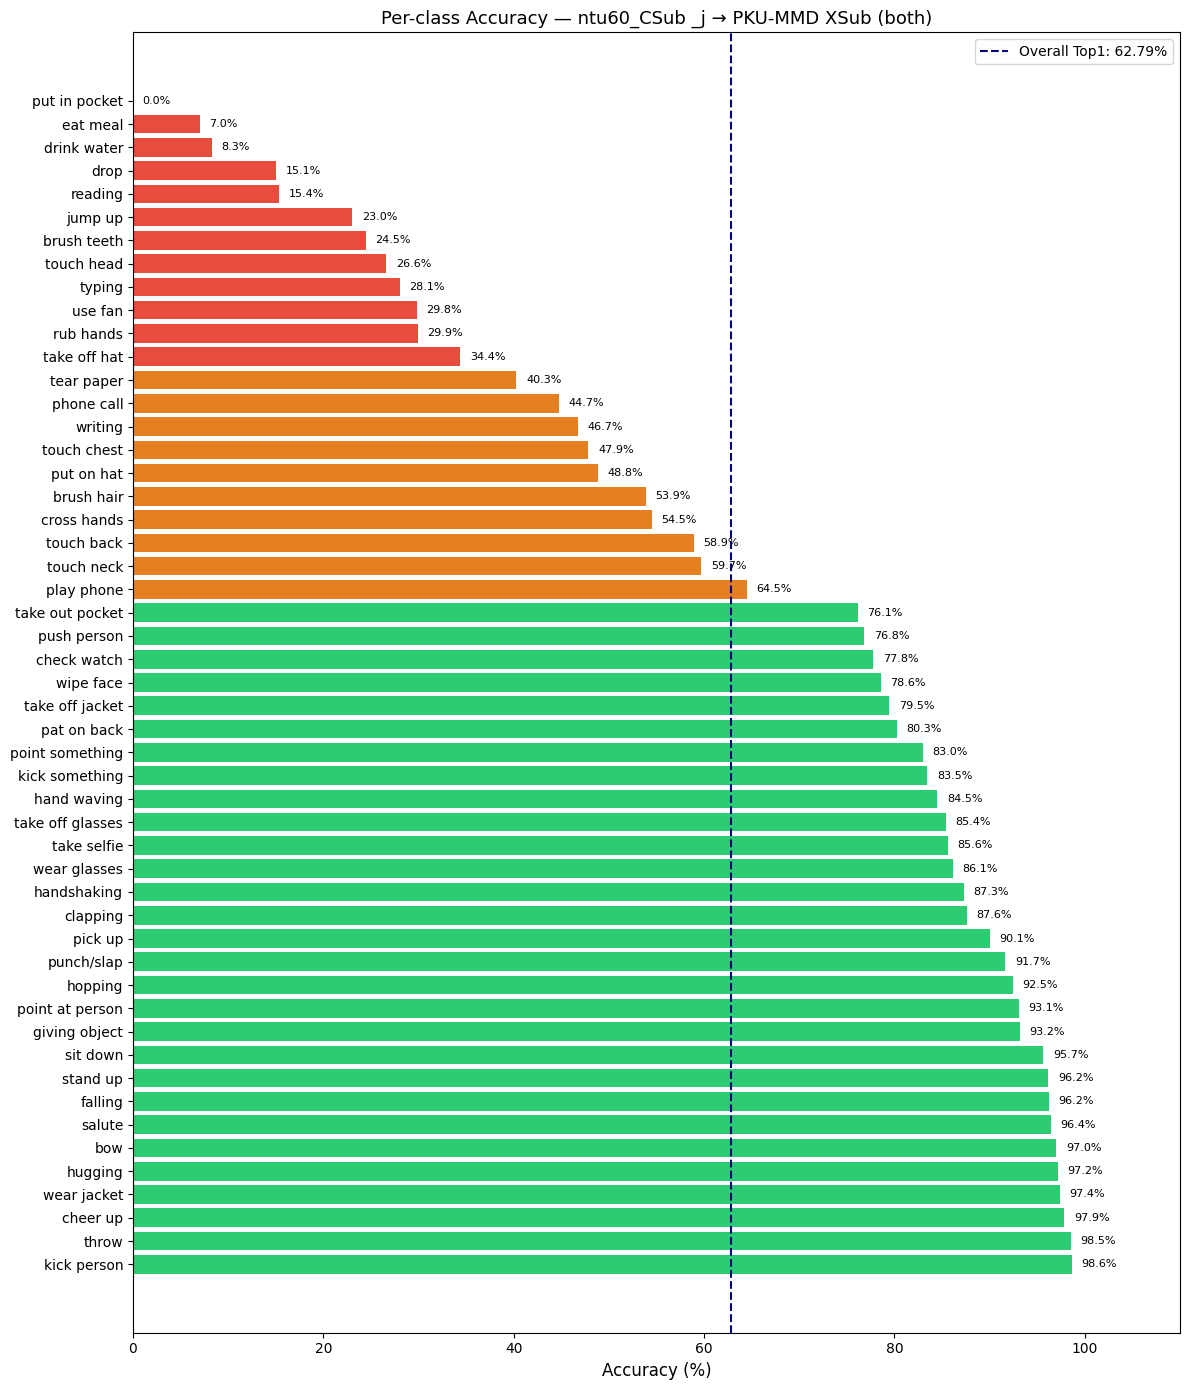

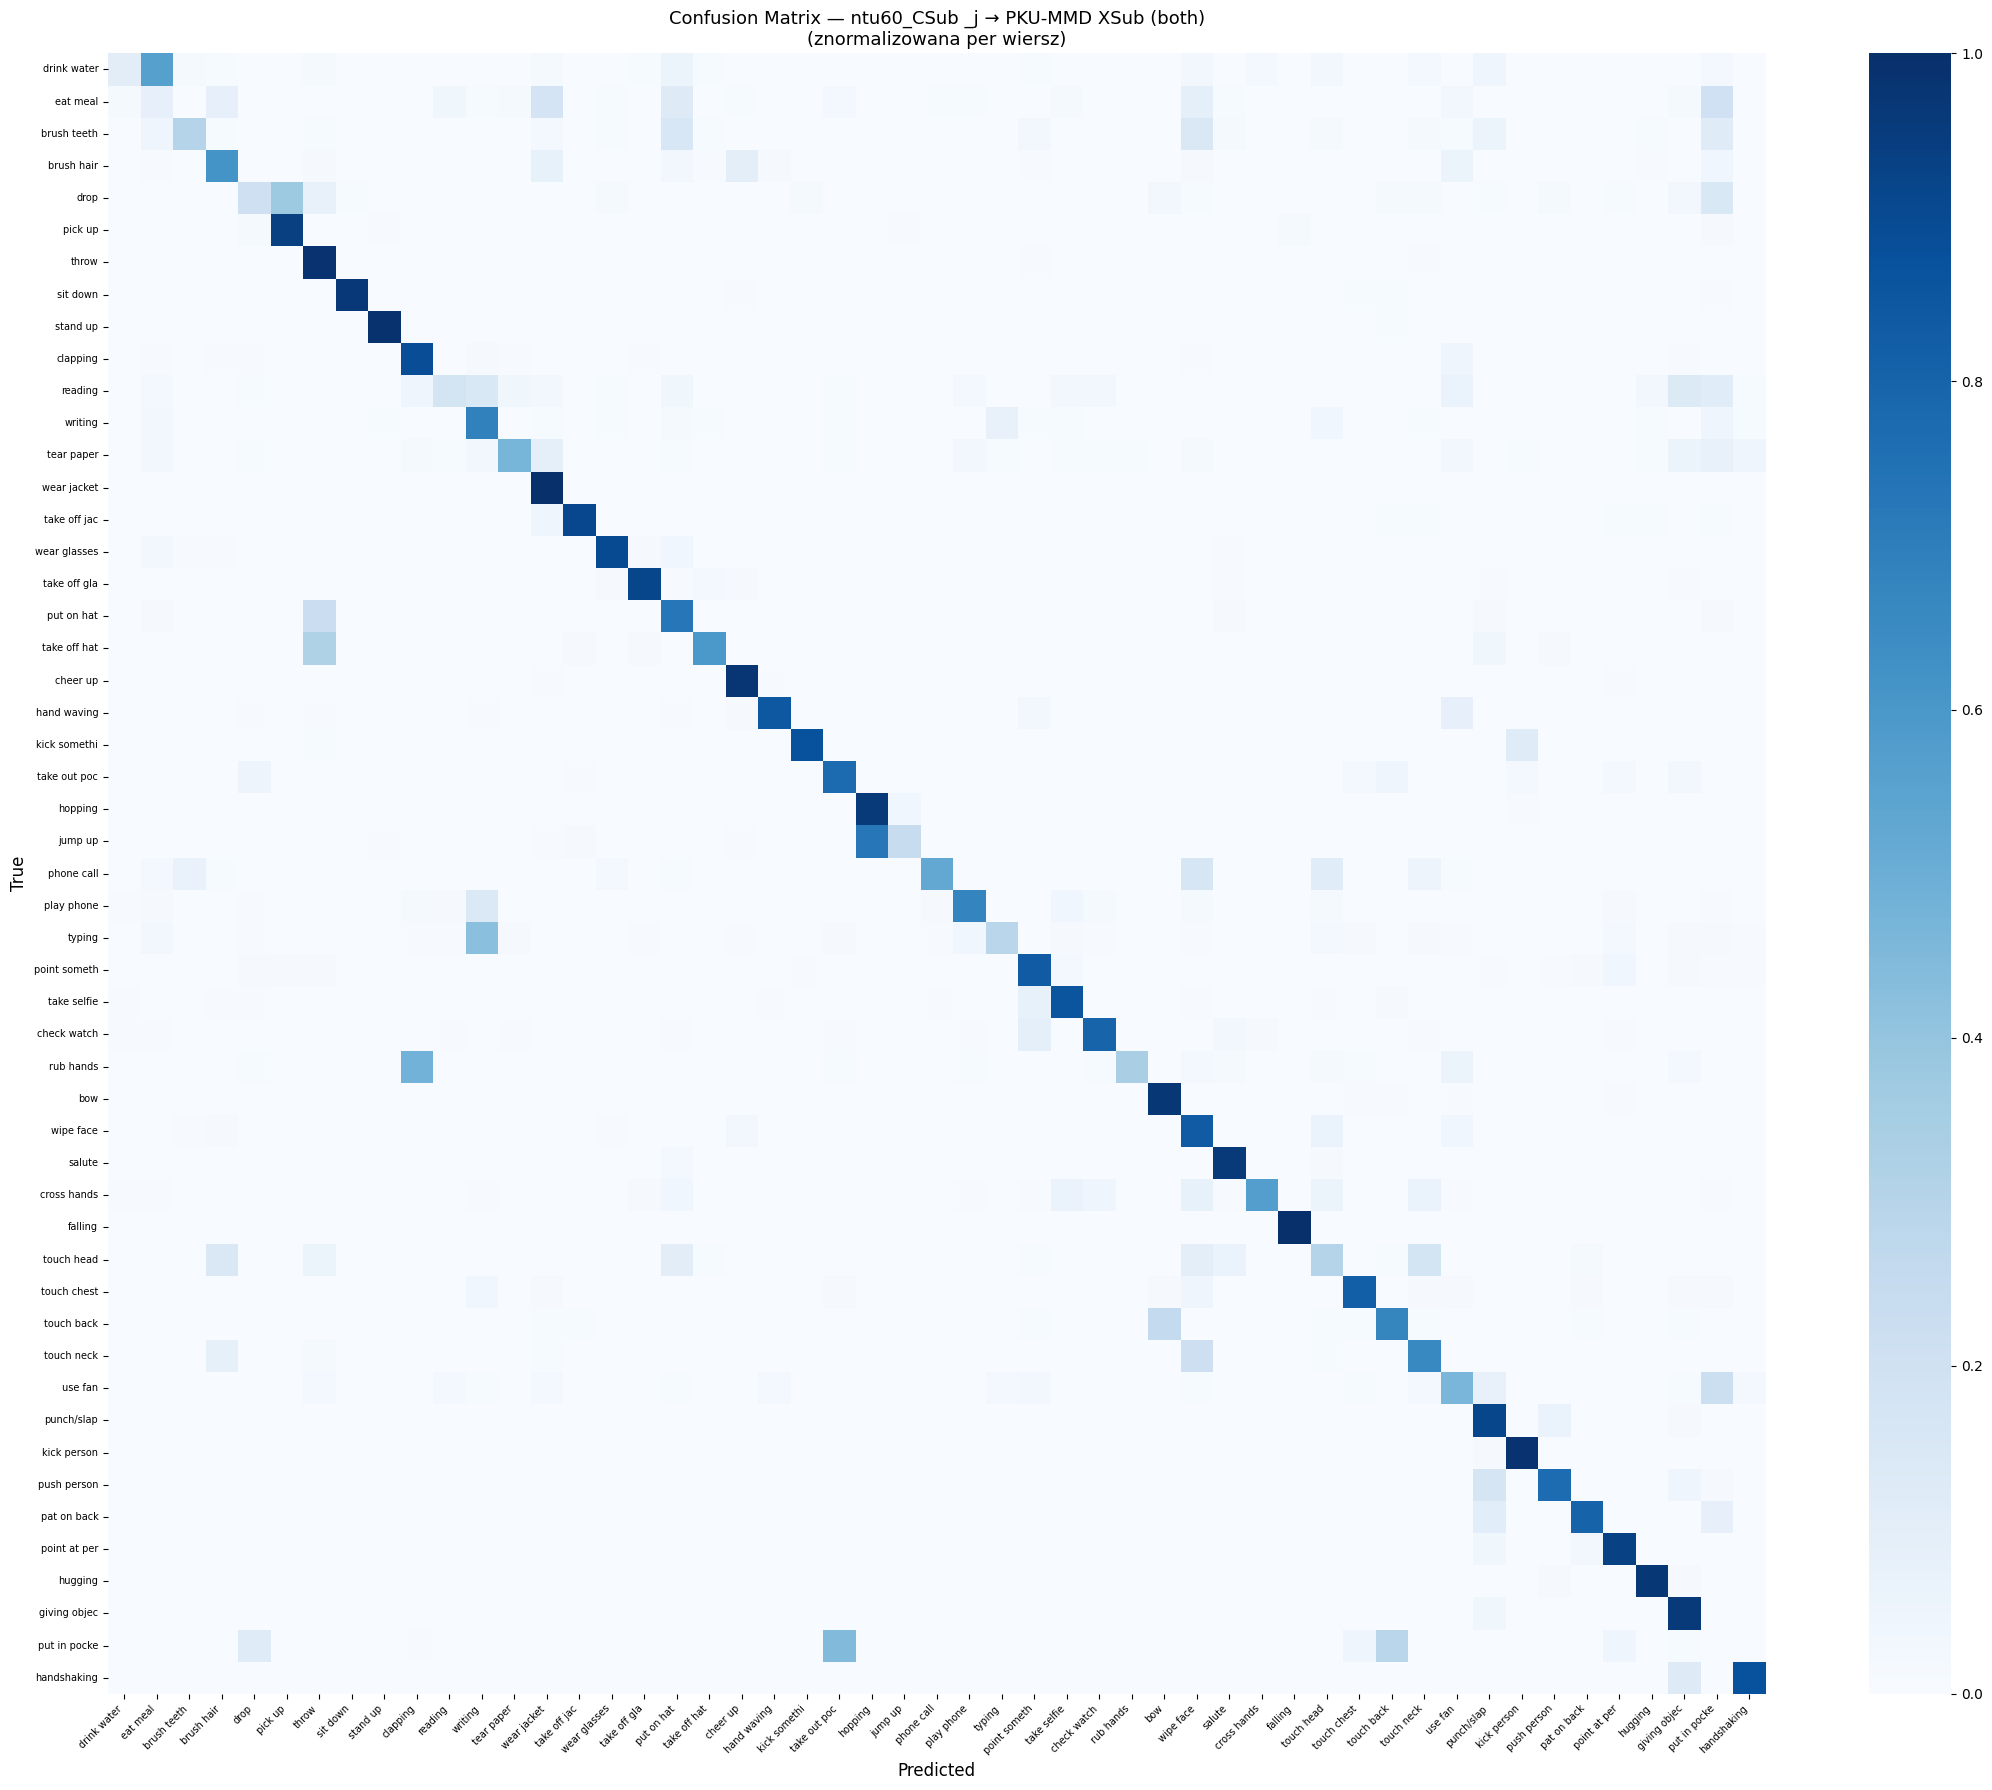

In [ ]:
import numpy as np, pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

WORK_DIR = './work_dir/ntu60_CSub/xview/SkateFormer_j'
NPZ_PATH = './data/ntu/PKU_XView_both.npz'

with open(f'{WORK_DIR}/epoch1_test_score.pkl', 'rb') as f:
    score_data = pickle.load(f)

data   = np.load(NPZ_PATH)
y_true = np.argmax(data['y_test'], axis=1)
keys   = sorted(score_data.keys(), key=lambda x: int(x.split('_')[1]))
scores = np.array([score_data[k] for k in keys])
y_pred = np.argmax(scores, axis=1)

print(f'Próbek: {len(y_true)}')
print(f'Overall Top1: {(y_true == y_pred).mean()*100:.2f}%')

PKU_TO_NTU = {
    1:34, 2:3, 3:2, 4:32, 5:21, 6:9, 7:39, 8:0, 9:4, 10:1,
    11:42, 12:55, 13:22, 14:57, 15:25, 16:54, 17:26, 18:50, 19:23, 20:27,
    21:52, 22:5, 23:28, 24:53, 25:30, 26:49, 27:51, 28:19, 29:56, 30:10,
    31:33, 32:37, 33:7, 34:8, 35:20, 36:18, 37:14, 38:24, 39:31, 40:12,
    41:6, 42:45, 43:44, 44:43, 45:46, 46:29, 47:48, 48:13, 49:17, 50:36, 51:11
}
PKU_NAMES = {
    1:'bow', 2:'brush hair', 3:'brush teeth', 4:'check watch', 5:'cheer up',
    6:'clapping', 7:'cross hands', 8:'drink water', 9:'drop', 10:'eat meal',
    11:'falling', 12:'giving object', 13:'hand waving', 14:'handshaking',
    15:'hopping', 16:'hugging', 17:'jump up', 18:'kick person', 19:'kick something',
    20:'phone call', 21:'pat on back', 22:'pick up', 23:'play phone',
    24:'point at person', 25:'point something', 26:'punch/slap', 27:'push person',
    28:'put on hat', 29:'put in pocket', 30:'reading', 31:'rub hands',
    32:'salute', 33:'sit down', 34:'stand up', 35:'take off hat',
    36:'take off glasses', 37:'take off jacket', 38:'take out pocket',
    39:'take selfie', 40:'tear paper', 41:'throw', 42:'touch back',
    43:'touch chest', 44:'touch head', 45:'touch neck', 46:'typing',
    47:'use fan', 48:'wear jacket', 49:'wear glasses', 50:'wipe face', 51:'writing'
}
NTU_TO_NAME = {v: PKU_NAMES[k] for k, v in PKU_TO_NTU.items()}
used_ntu    = sorted(NTU_TO_NAME.keys())

print('\n── Per-class accuracy ──────────────────────────────────────────')
print(f'{"PKU Akcja":<25} {"NTU idx":>7} {"Correct":>8} {"Total":>7} {"Acc":>7}')
print('-' * 60)
per_class = []
for ntu_idx in used_ntu:
    mask    = (y_true == ntu_idx)
    total   = mask.sum()
    if total == 0: continue
    correct = (y_pred[mask] == ntu_idx).sum()
    acc     = correct / total * 100
    per_class.append((NTU_TO_NAME[ntu_idx], ntu_idx, correct, total, acc))
    print(f'{NTU_TO_NAME[ntu_idx]:<25} {ntu_idx:>7} {correct:>8} {total:>7} {acc:>6.1f}%')

per_class_sorted = sorted(per_class, key=lambda x: x[4], reverse=True)
fig, ax = plt.subplots(figsize=(12, 14))
names  = [x[0] for x in per_class_sorted]
accs   = [x[4] for x in per_class_sorted]
colors = ['#2ecc71' if a >= 70 else '#e67e22' if a >= 40 else '#e74c3c' for a in accs]
bars   = ax.barh(names, accs, color=colors)
overall = (y_true == y_pred).mean() * 100
ax.axvline(x=overall, color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall Top1: {overall:.2f}%')
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-class Accuracy — ntu60_CSub _j → PKU-MMD XSub (both)', fontsize=13)
ax.legend()
ax.set_xlim(0, 110)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

mask_used  = np.isin(y_true, used_ntu)
y_true_cm  = y_true[mask_used]
y_pred_cm  = y_pred[mask_used]
remap      = {ntu: i for i, ntu in enumerate(used_ntu)}
y_true_r   = np.array([remap[v] for v in y_true_cm])
y_pred_r   = np.array([remap[v] if v in remap else len(used_ntu) for v in y_pred_cm])
cm         = confusion_matrix(y_true_r, y_pred_r, labels=list(range(len(used_ntu))))
cm_norm    = cm.astype(float) / cm.sum(axis=1, keepdims=True)
short_names = [NTU_TO_NAME[c][:12] for c in used_ntu]
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(cm_norm, annot=False, cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix — ntu60_CSub _j → PKU-MMD XSub (both)\n(znormalizowana per wiersz)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
INTERACTION_NTU = [49, 50, 51, 52, 53, 54, 55, 57]
INT_NAMES = {
    49: 'punch/slap', 50: 'kick person', 51: 'push person', 52: 'pat on back',
    53: 'point at person', 54: 'hugging', 55: 'giving object', 57: 'handshaking'
}

mask_int   = np.isin(y_true, INTERACTION_NTU)
y_true_int = y_true[mask_int]
y_pred_int = y_pred[mask_int]

print(f'Próbek interakcyjnych: {mask_int.sum()}')
print(f'Interaction Top1: {(y_true_int == y_pred_int).mean()*100:.2f}%')
print()
print(f'{"Akcja":<20} {"Correct":>8} {"Total":>7} {"Acc":>7}')
print('-' * 45)
for ntu_idx in sorted(INTERACTION_NTU):
    mask    = (y_true_int == ntu_idx)
    total   = mask.sum()
    if total == 0: continue
    correct = (y_pred_int[mask] == ntu_idx).sum()
    print(f'{INT_NAMES[ntu_idx]:<20} {correct:>8} {total:>7} {correct/total*100:>6.1f}%')


Próbek interakcyjnych: 571
Interaction Top1: 89.84%

Akcja                 Correct   Total     Acc
---------------------------------------------
punch/slap                 66      72   91.7%
kick person                71      72   98.6%
push person                53      69   76.8%
pat on back                57      71   80.3%
point at person            67      72   93.1%
hugging                    69      71   97.2%
giving object              68      73   93.2%
handshaking                62      71   87.3%


In [ ]:
#Run C - XSub pipline baseline, dane po korekcie mapowanie 29,38 to 24.
import yaml

NPZ_PATH = './data/ntu/PKU_XSub.npz'
WORK_DIR = './work_dir/ntu60_CSub/xsub_baseline/SkateFormer_j'
PT_PATH  = '/content/SkateFormer/SkateFormer_j.pt'

config = {
    'seed': 1,
    'num_worker': 4,
    'work_dir': WORK_DIR,
    'phase': 'test',
    'weights': PT_PATH,
    'feeder': 'feeders.feeder_ntu.Feeder',
    'train_feeder_args': {
        'data_path': NPZ_PATH, 'split': 'train', 'debug': False,
        'window_size': 64, 'p_interval': [0.5, 1], 'aug_method': 'a123489',
        'intra_p': 0.5, 'inter_p': 0.2, 'thres': 64, 'uniform': True, 'partition': True
    },
    'test_feeder_args': {
        'data_path': NPZ_PATH, 'split': 'test', 'window_size': 64,
        'p_interval': [0.95], 'thres': 64, 'uniform': True, 'partition': True, 'debug': False
    },
    'model': 'model.SkateFormer.SkateFormer_',
    'model_args': {
        'num_classes': 60, 'num_people': 2, 'num_points': 24, 'kernel_size': 7,
        'num_heads': 32, 'attn_drop': 0.5, 'head_drop': 0.0, 'rel': True,
        'drop_path': 0.2, 'type_1_size': [8, 8], 'type_2_size': [8, 12],
        'type_3_size': [8, 8], 'type_4_size': [8, 12], 'mlp_ratio': 4.0, 'index_t': True
    },
    'device': [0], 'batch_size': 128, 'test_batch_size': 128,
    'num_epoch': 1, 'save_score': True
}

os.makedirs('config/test/pku_xsub', exist_ok=True)
os.makedirs(WORK_DIR, exist_ok=True)
with open('config/test/pku_xsub/SkateFormer_j.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

!python main.py --config config/test/pku_xsub/SkateFormer_j.yaml


<function SkateFormer_ at 0x7ee60a91c5e0>
/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[ Sat Sep  5 19:16:22 2026 ] Load weights from /content/SkateFormer/SkateFormer_j.pt.
[ Sat Sep  5 19:16:24 2026 ] Model:   model.SkateFormer.SkateFormer_.
[ Sat Sep  5 19:16:24 2026 ] Weights: /content/SkateFormer/SkateFormer_j.pt.
[ Sat Sep  5 19:16:24 2026 ] Eval epoch: 1
100% 22/22 [00:04<00:00,  5.33it/s]
Accuracy:  0.6528189910979229  model:  
[ Sat Sep  5 19:16:28 2026 ] 	Mean test loss of 22 batches: 1.6880487908016553.
[ Sat Sep  5 19:16:28 2026 ] 	Top1: 65.28%
[ Sat Sep  5 19:16:28 2026 ] 	Top5: 82.12%
/content/SkateFormer/main.py:450: RuntimeWarning: invalid value encountered in divide
  each_acc = list_diag / list_raw_su

Próbek: 2696
Overall Top1: 65.28%

── Per-class accuracy ──────────────────────────────────────────
PKU Akcja                 NTU idx  Correct   Total     Acc
------------------------------------------------------------
drink water                     0       10      60   16.7%
eat meal                        1        5      57    8.8%
brush teeth                     2       21      54   38.9%
brush hair                      3       26      54   48.1%
drop                            4       16      54   29.6%
pick up                         5       62      63   98.4%
throw                           6       53      54   98.1%
sit down                        7       54      60   90.0%
stand up                        8       60      60  100.0%
clapping                        9       43      57   75.4%
reading                        10        7      53   13.2%
writing                        11       16      57   28.1%
tear paper                     12        7      47   14.9%
wear jacket  

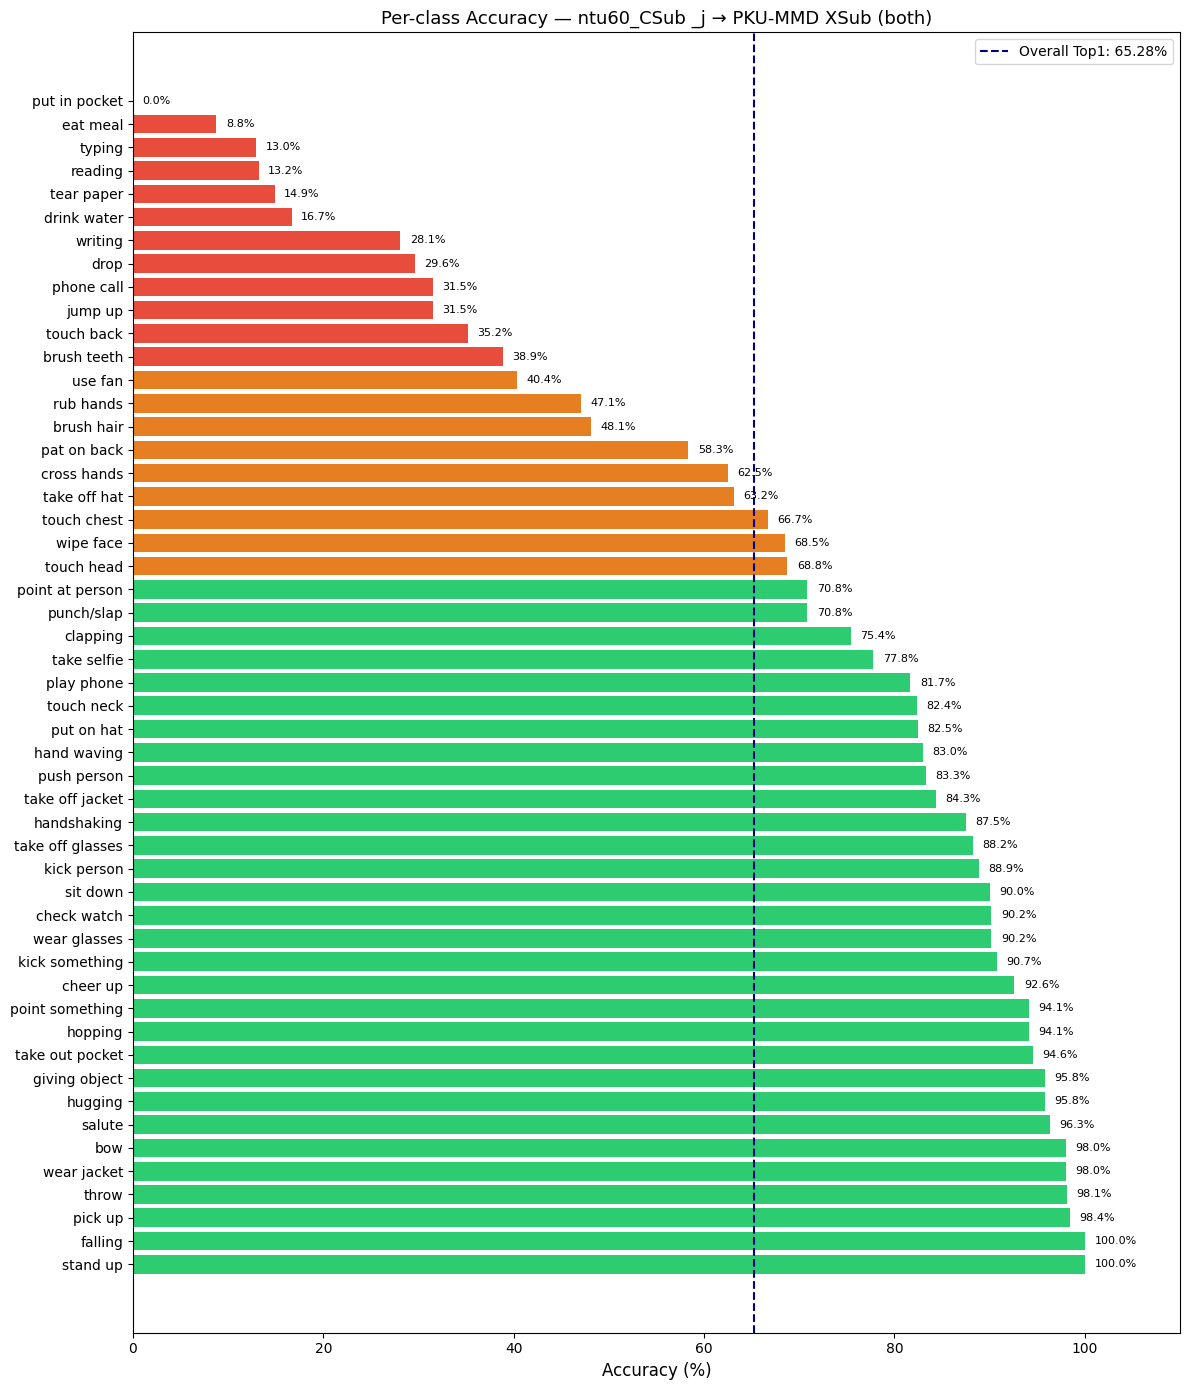

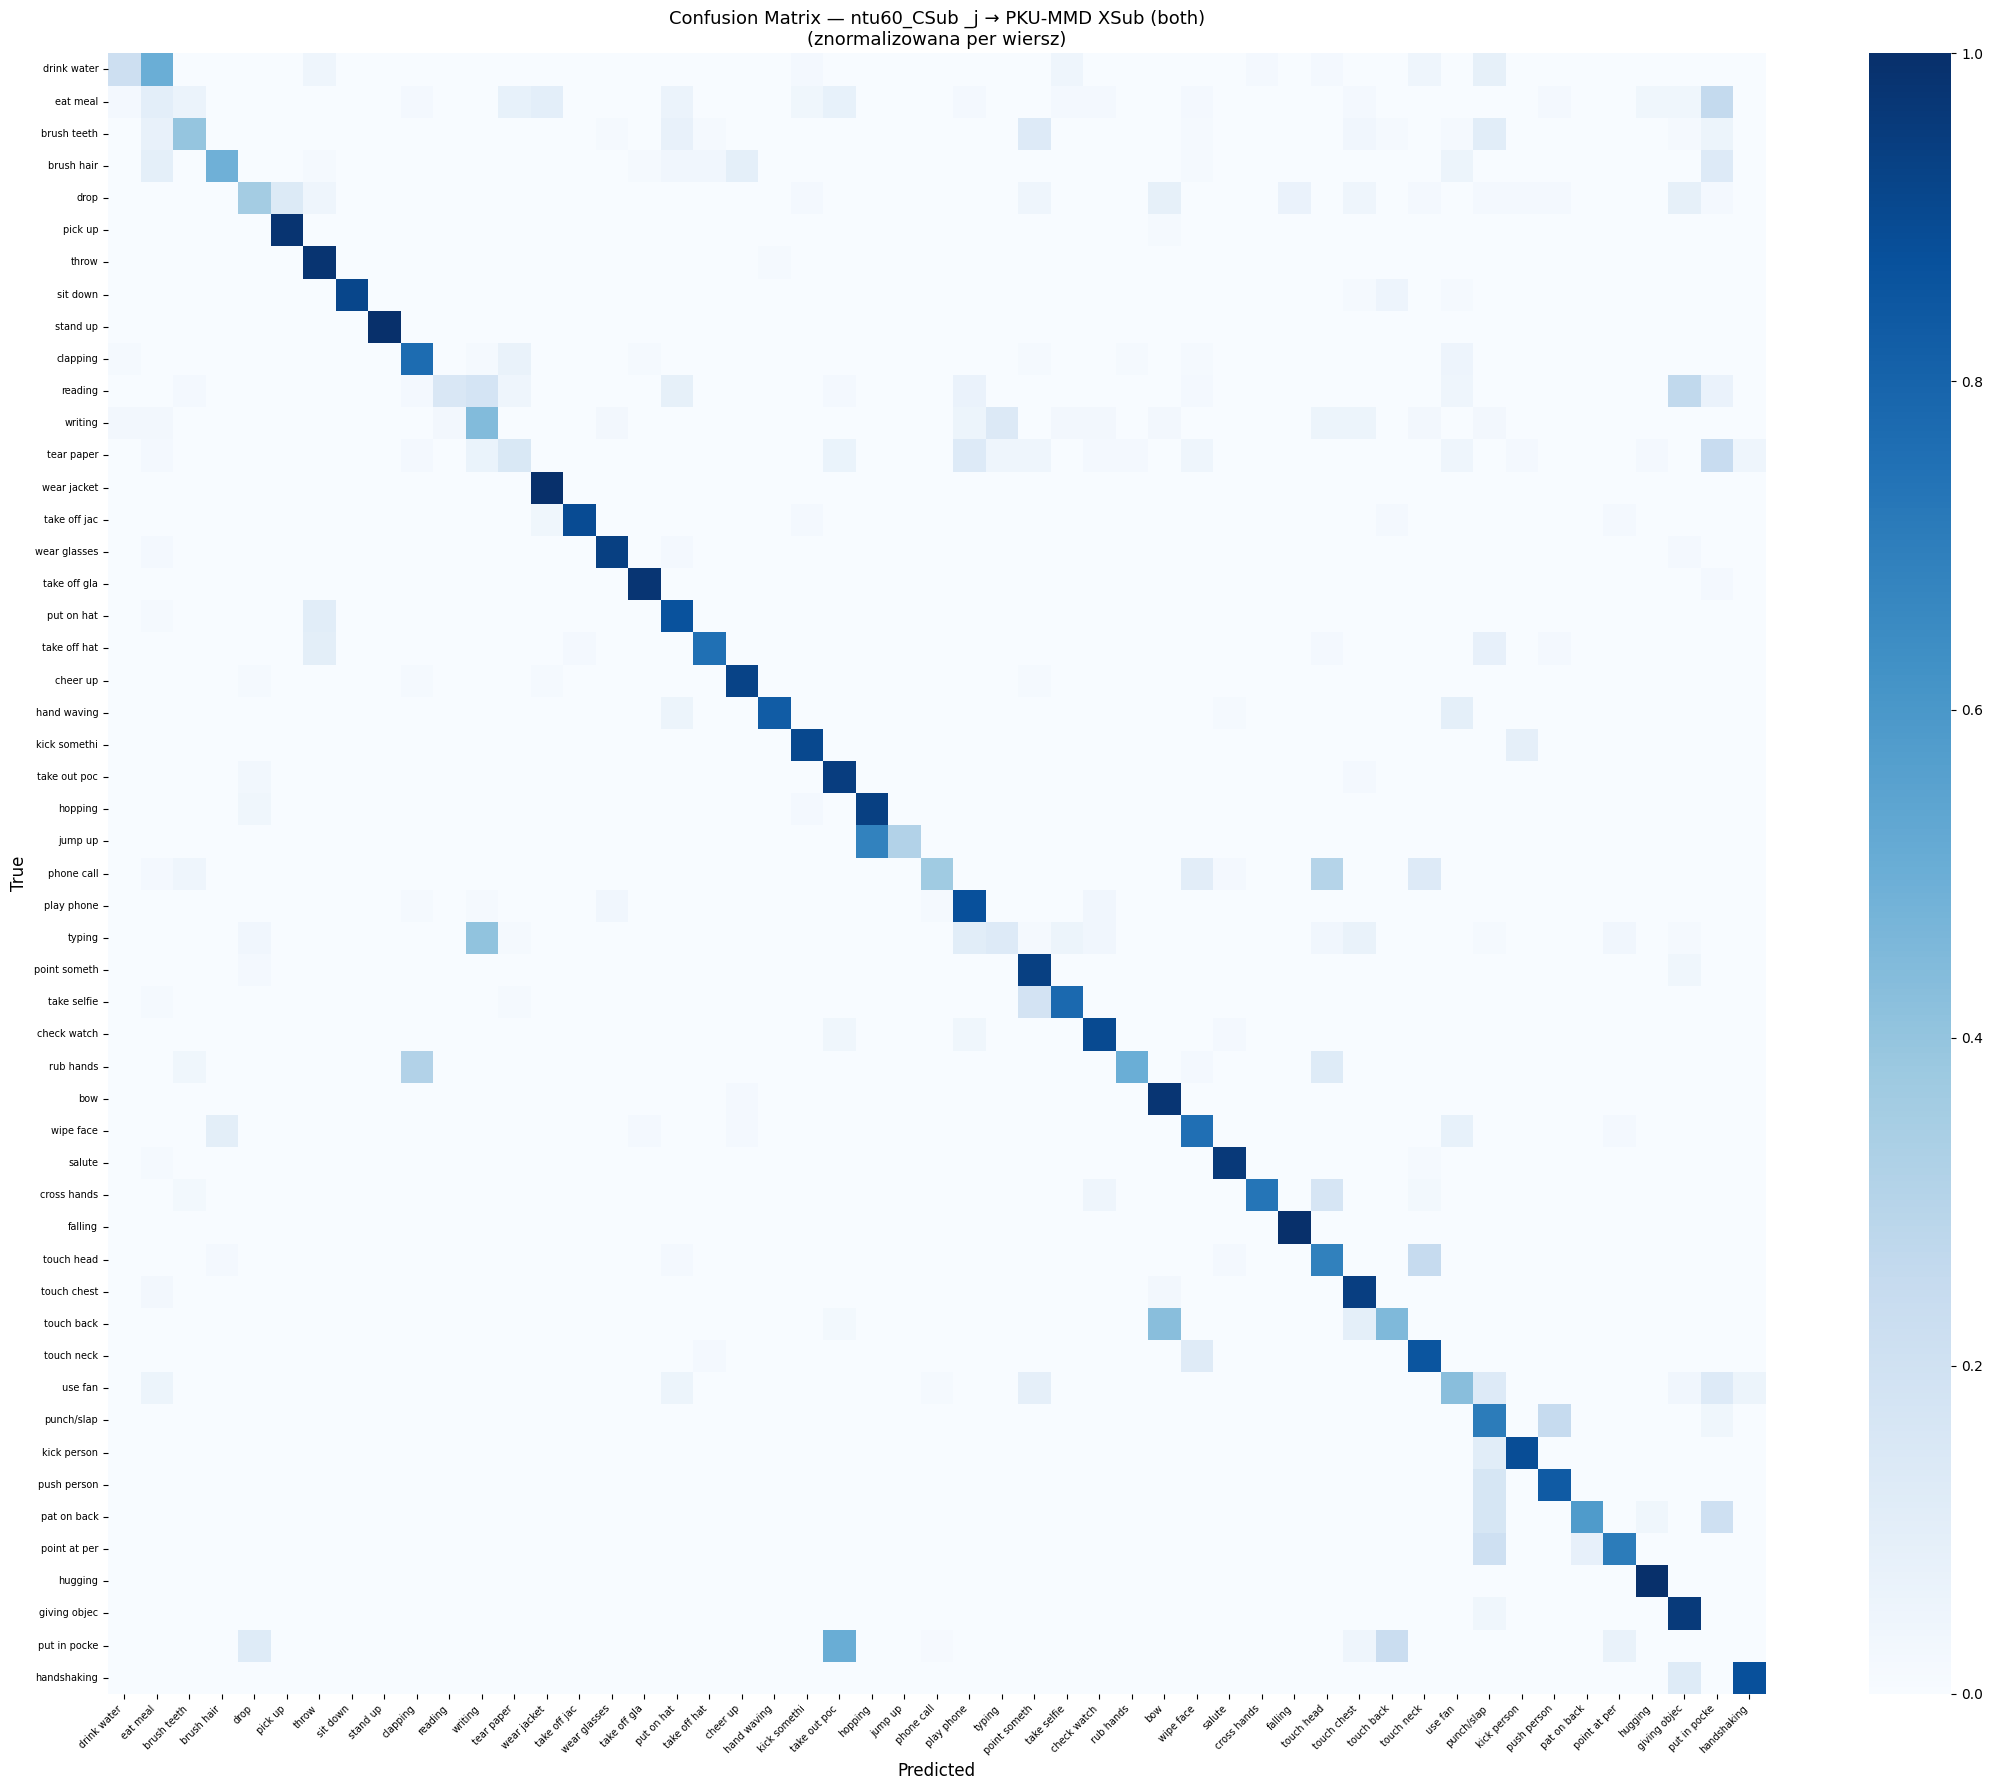

In [ ]:
import numpy as np, pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

NPZ_PATH = './data/ntu/PKU_XSub.npz'
WORK_DIR = './work_dir/ntu60_CSub/xsub_baseline/SkateFormer_j'

with open(f'{WORK_DIR}/epoch1_test_score.pkl', 'rb') as f:
    score_data = pickle.load(f)

data   = np.load(NPZ_PATH)
y_true = np.argmax(data['y_test'], axis=1)
keys   = sorted(score_data.keys(), key=lambda x: int(x.split('_')[1]))
scores = np.array([score_data[k] for k in keys])
y_pred = np.argmax(scores, axis=1)

print(f'Próbek: {len(y_true)}')
print(f'Overall Top1: {(y_true == y_pred).mean()*100:.2f}%')

PKU_TO_NTU = {
    1:34, 2:3, 3:2, 4:32, 5:21, 6:9, 7:39, 8:0, 9:4, 10:1,
    11:42, 12:55, 13:22, 14:57, 15:25, 16:54, 17:26, 18:50, 19:23, 20:27,
    21:52, 22:5, 23:28, 24:53, 25:30, 26:49, 27:51, 28:19, 29:56, 30:10,
    31:33, 32:37, 33:7, 34:8, 35:20, 36:18, 37:14, 38:24, 39:31, 40:12,
    41:6, 42:45, 43:44, 44:43, 45:46, 46:29, 47:48, 48:13, 49:17, 50:36, 51:11
}
PKU_NAMES = {
    1:'bow', 2:'brush hair', 3:'brush teeth', 4:'check watch', 5:'cheer up',
    6:'clapping', 7:'cross hands', 8:'drink water', 9:'drop', 10:'eat meal',
    11:'falling', 12:'giving object', 13:'hand waving', 14:'handshaking',
    15:'hopping', 16:'hugging', 17:'jump up', 18:'kick person', 19:'kick something',
    20:'phone call', 21:'pat on back', 22:'pick up', 23:'play phone',
    24:'point at person', 25:'point something', 26:'punch/slap', 27:'push person',
    28:'put on hat', 29:'put in pocket', 30:'reading', 31:'rub hands',
    32:'salute', 33:'sit down', 34:'stand up', 35:'take off hat',
    36:'take off glasses', 37:'take off jacket', 38:'take out pocket',
    39:'take selfie', 40:'tear paper', 41:'throw', 42:'touch back',
    43:'touch chest', 44:'touch head', 45:'touch neck', 46:'typing',
    47:'use fan', 48:'wear jacket', 49:'wear glasses', 50:'wipe face', 51:'writing'
}
NTU_TO_NAME = {v: PKU_NAMES[k] for k, v in PKU_TO_NTU.items()}
used_ntu    = sorted(NTU_TO_NAME.keys())

print('\n── Per-class accuracy ──────────────────────────────────────────')
print(f'{"PKU Akcja":<25} {"NTU idx":>7} {"Correct":>8} {"Total":>7} {"Acc":>7}')
print('-' * 60)
per_class = []
for ntu_idx in used_ntu:
    mask    = (y_true == ntu_idx)
    total   = mask.sum()
    if total == 0: continue
    correct = (y_pred[mask] == ntu_idx).sum()
    acc     = correct / total * 100
    per_class.append((NTU_TO_NAME[ntu_idx], ntu_idx, correct, total, acc))
    print(f'{NTU_TO_NAME[ntu_idx]:<25} {ntu_idx:>7} {correct:>8} {total:>7} {acc:>6.1f}%')

per_class_sorted = sorted(per_class, key=lambda x: x[4], reverse=True)
fig, ax = plt.subplots(figsize=(12, 14))
names  = [x[0] for x in per_class_sorted]
accs   = [x[4] for x in per_class_sorted]
colors = ['#2ecc71' if a >= 70 else '#e67e22' if a >= 40 else '#e74c3c' for a in accs]
bars   = ax.barh(names, accs, color=colors)
overall = (y_true == y_pred).mean() * 100
ax.axvline(x=overall, color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall Top1: {overall:.2f}%')
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-class Accuracy — ntu60_CSub _j → PKU-MMD XSub (both)', fontsize=13)
ax.legend()
ax.set_xlim(0, 110)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

mask_used  = np.isin(y_true, used_ntu)
y_true_cm  = y_true[mask_used]
y_pred_cm  = y_pred[mask_used]
remap      = {ntu: i for i, ntu in enumerate(used_ntu)}
y_true_r   = np.array([remap[v] for v in y_true_cm])
y_pred_r   = np.array([remap[v] if v in remap else len(used_ntu) for v in y_pred_cm])
cm         = confusion_matrix(y_true_r, y_pred_r, labels=list(range(len(used_ntu))))
cm_norm    = cm.astype(float) / cm.sum(axis=1, keepdims=True)
short_names = [NTU_TO_NAME[c][:12] for c in used_ntu]
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(cm_norm, annot=False, cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix — ntu60_CSub _j → PKU-MMD XSub (both)\n(znormalizowana per wiersz)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
INTERACTION_NTU = [49, 50, 51, 52, 53, 54, 55, 57]
INT_NAMES = {
    49: 'punch/slap', 50: 'kick person', 51: 'push person', 52: 'pat on back',
    53: 'point at person', 54: 'hugging', 55: 'giving object', 57: 'handshaking'
}

mask_int   = np.isin(y_true, INTERACTION_NTU)
y_true_int = y_true[mask_int]
y_pred_int = y_pred[mask_int]

print(f'Próbek interakcyjnych: {mask_int.sum()}')
print(f'Interaction Top1: {(y_true_int == y_pred_int).mean()*100:.2f}%')
print()
print(f'{"Akcja":<20} {"Correct":>8} {"Total":>7} {"Acc":>7}')
print('-' * 45)
for ntu_idx in sorted(INTERACTION_NTU):
    mask    = (y_true_int == ntu_idx)
    total   = mask.sum()
    if total == 0: continue
    correct = (y_pred_int[mask] == ntu_idx).sum()
    print(f'{INT_NAMES[ntu_idx]:<20} {correct:>8} {total:>7} {correct/total*100:>6.1f}%')


Próbek interakcyjnych: 195
Interaction Top1: 81.54%

Akcja                 Correct   Total     Acc
---------------------------------------------
punch/slap                 17      24   70.8%
kick person                24      27   88.9%
push person                20      24   83.3%
pat on back                14      24   58.3%
point at person            17      24   70.8%
hugging                    23      24   95.8%
giving object              23      24   95.8%
handshaking                21      24   87.5%


In [ ]:
#Run D - XView pipline baseline, dane po korekcie mapowanie 29,38 to 24.
import yaml

NPZ_PATH = './data/ntu/PKU_XView.npz'
WORK_DIR = './work_dir/ntu60_CSub/xview_baseline/SkateFormer_j'
PT_PATH  = '/content/SkateFormer/SkateFormer_j.pt'

config = {
    'seed': 1,
    'num_worker': 4,
    'work_dir': WORK_DIR,
    'phase': 'test',
    'weights': PT_PATH,
    'feeder': 'feeders.feeder_ntu.Feeder',
    'train_feeder_args': {
        'data_path': NPZ_PATH, 'split': 'train', 'debug': False,
        'window_size': 64, 'p_interval': [0.5, 1], 'aug_method': 'a123489',
        'intra_p': 0.5, 'inter_p': 0.2, 'thres': 64, 'uniform': True, 'partition': True
    },
    'test_feeder_args': {
        'data_path': NPZ_PATH, 'split': 'test', 'window_size': 64,
        'p_interval': [0.95], 'thres': 64, 'uniform': True, 'partition': True, 'debug': False
    },
    'model': 'model.SkateFormer.SkateFormer_',
    'model_args': {
        'num_classes': 60, 'num_people': 2, 'num_points': 24, 'kernel_size': 7,
        'num_heads': 32, 'attn_drop': 0.5, 'head_drop': 0.0, 'rel': True,
        'drop_path': 0.2, 'type_1_size': [8, 8], 'type_2_size': [8, 12],
        'type_3_size': [8, 8], 'type_4_size': [8, 12], 'mlp_ratio': 4.0, 'index_t': True
    },
    'device': [0], 'batch_size': 128, 'test_batch_size': 128,
    'num_epoch': 1, 'save_score': True
}

os.makedirs('config/test/pku_xsub', exist_ok=True)
os.makedirs(WORK_DIR, exist_ok=True)
with open('config/test/pku_xsub/SkateFormer_j.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

!python main.py --config config/test/pku_xsub/SkateFormer_j.yaml

<function SkateFormer_ at 0x7a21bef145e0>
/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[ Sat Sep  5 19:16:38 2026 ] Load weights from /content/SkateFormer/SkateFormer_j.pt.
[ Sat Sep  5 19:16:43 2026 ] Model:   model.SkateFormer.SkateFormer_.
[ Sat Sep  5 19:16:43 2026 ] Weights: /content/SkateFormer/SkateFormer_j.pt.
[ Sat Sep  5 19:16:43 2026 ] Eval epoch: 1
100% 56/56 [00:09<00:00,  5.69it/s]
Accuracy:  0.6504691219717127  model:  
[ Sat Sep  5 19:16:53 2026 ] 	Mean test loss of 56 batches: 1.6655733798231398.
[ Sat Sep  5 19:16:53 2026 ] 	Top1: 65.05%
[ Sat Sep  5 19:16:53 2026 ] 	Top5: 82.37%
/content/SkateFormer/main.py:450: RuntimeWarning: invalid value encountered in divide
  each_acc = list_diag / list_raw_su

Próbek: 7141
Overall Top1: 65.05%

── Per-class accuracy ──────────────────────────────────────────
PKU Akcja                 NTU idx  Correct   Total     Acc
------------------------------------------------------------
drink water                     0       19     157   12.1%
eat meal                        1       12     142    8.5%
brush teeth                     2       42     143   29.4%
brush hair                      3       82     154   53.2%
drop                            4       32     146   21.9%
pick up                         5      152     171   88.9%
throw                           6      135     137   98.5%
sit down                        7      177     184   96.2%
stand up                        8      180     183   98.4%
clapping                        9      123     145   84.8%
reading                        10       23     143   16.1%
writing                        11       58     152   38.2%
tear paper                     12       68     139   48.9%
wear jacket  

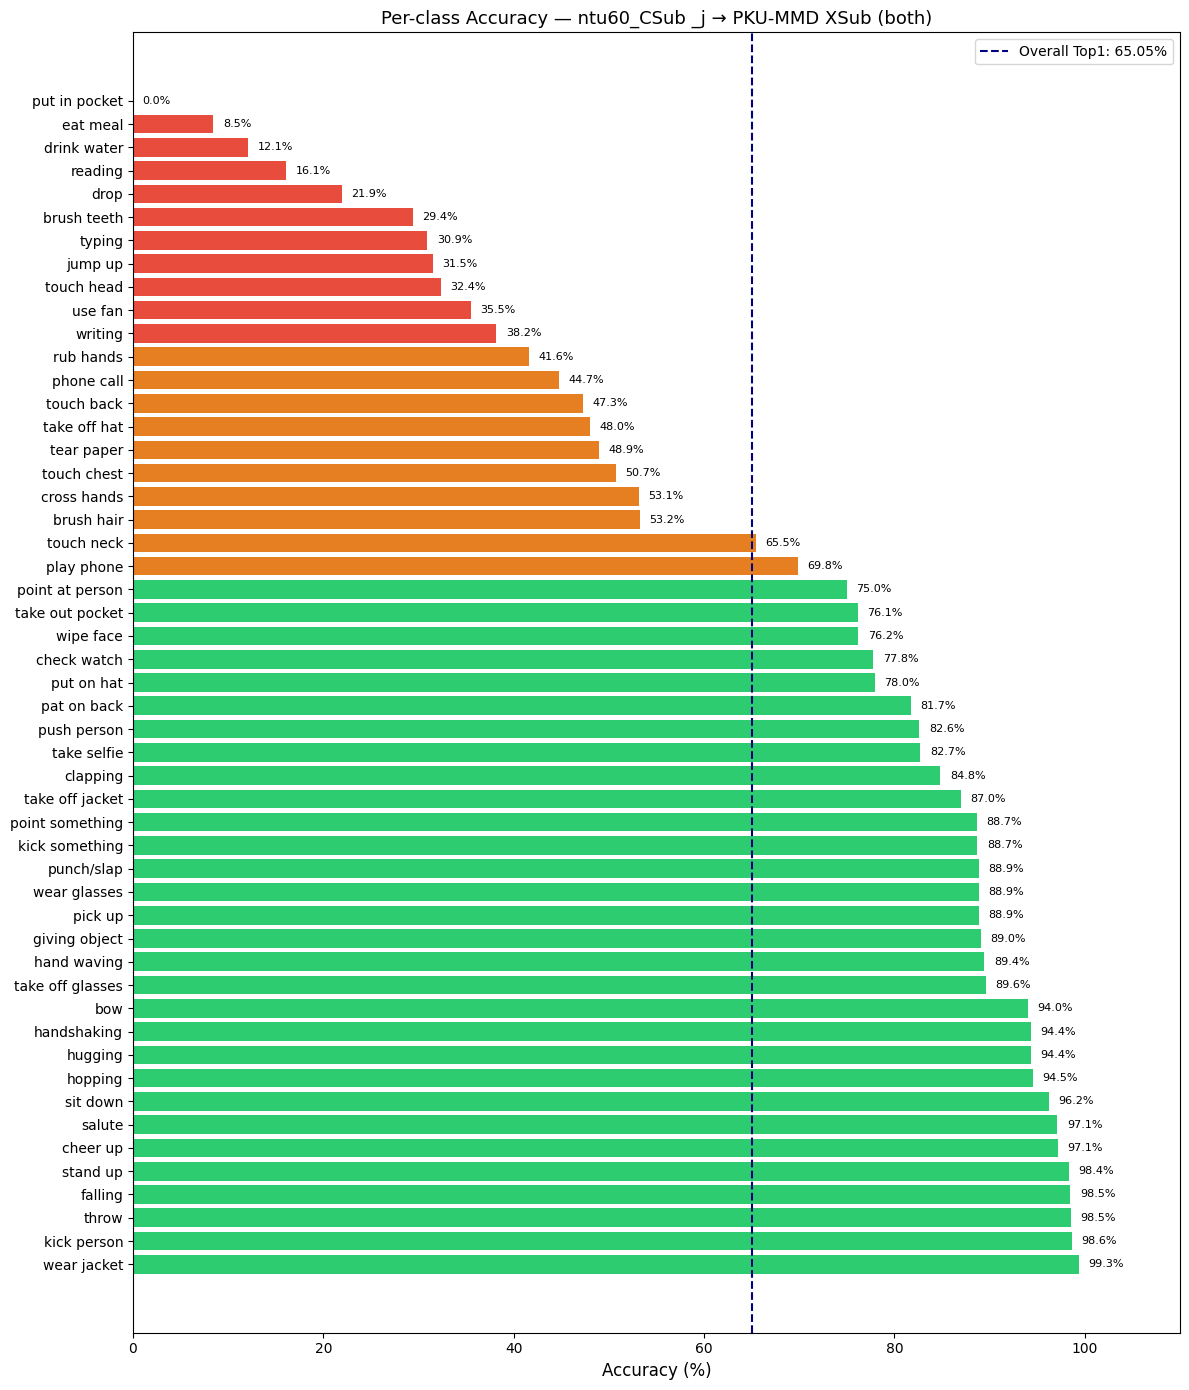

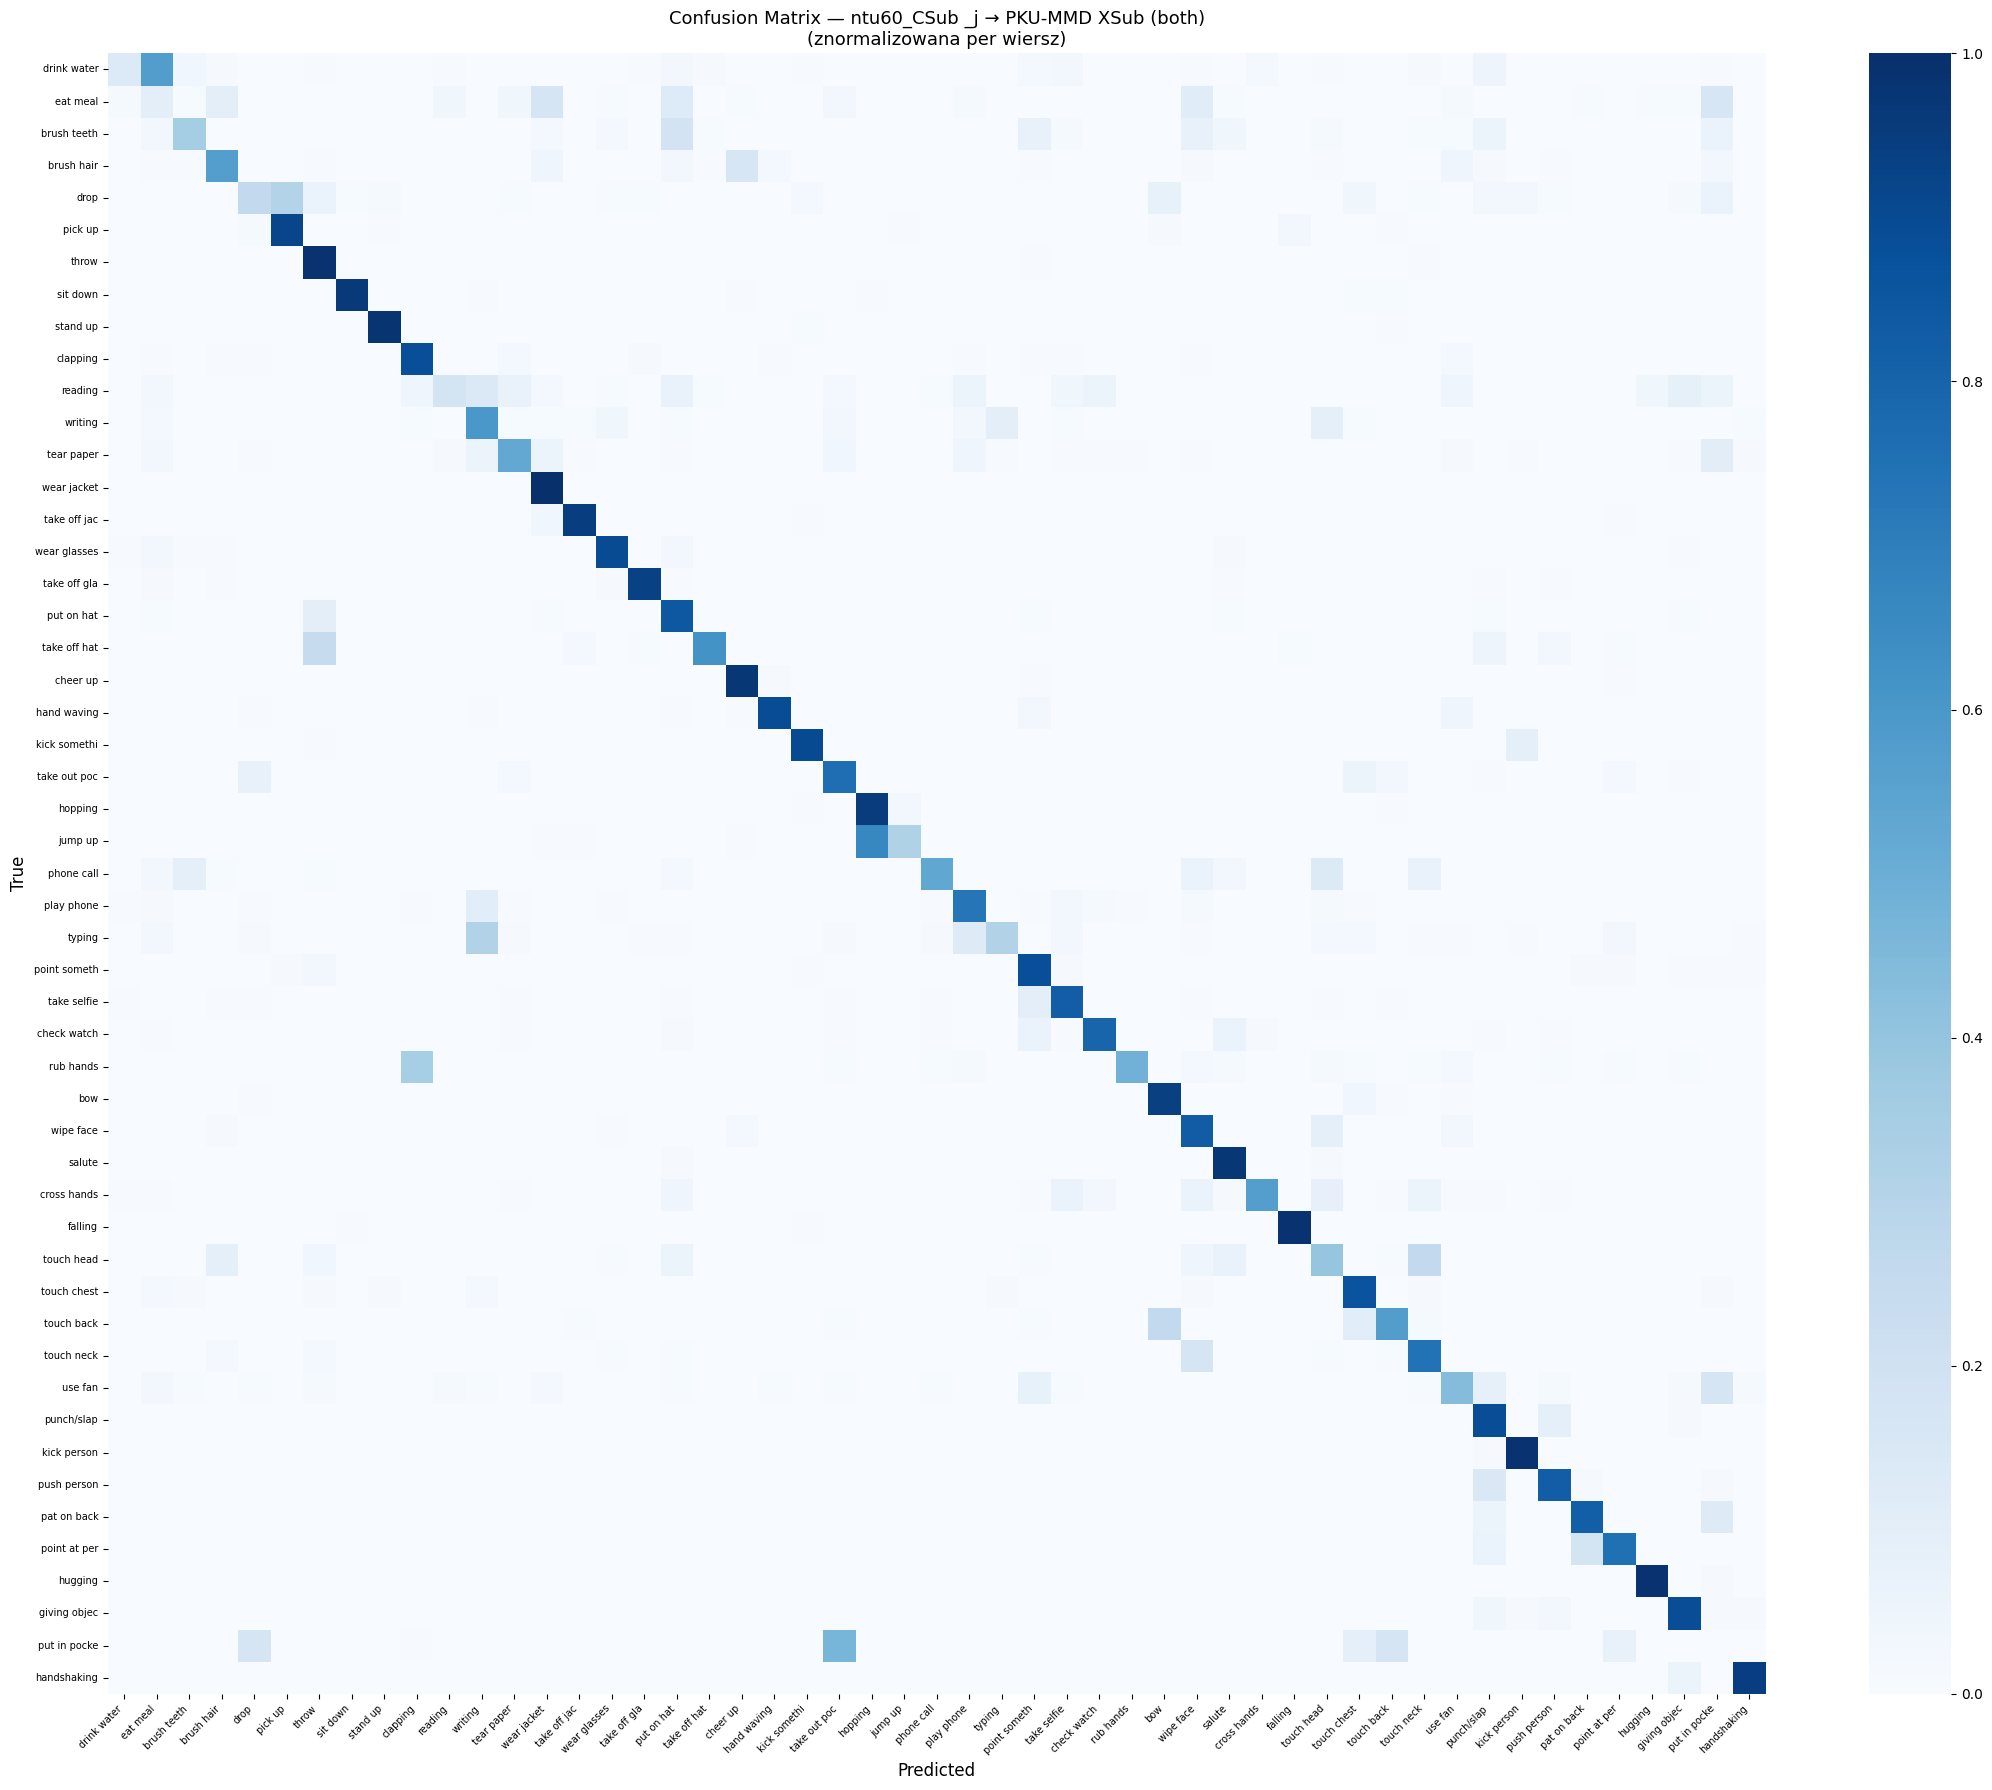

In [ ]:
import numpy as np, pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

NPZ_PATH = './data/ntu/PKU_XView.npz'
WORK_DIR = './work_dir/ntu60_CSub/xview_baseline/SkateFormer_j'

with open(f'{WORK_DIR}/epoch1_test_score.pkl', 'rb') as f:
    score_data = pickle.load(f)

data   = np.load(NPZ_PATH)
y_true = np.argmax(data['y_test'], axis=1)
keys   = sorted(score_data.keys(), key=lambda x: int(x.split('_')[1]))
scores = np.array([score_data[k] for k in keys])
y_pred = np.argmax(scores, axis=1)

print(f'Próbek: {len(y_true)}')
print(f'Overall Top1: {(y_true == y_pred).mean()*100:.2f}%')

PKU_TO_NTU = {
    1:34, 2:3, 3:2, 4:32, 5:21, 6:9, 7:39, 8:0, 9:4, 10:1,
    11:42, 12:55, 13:22, 14:57, 15:25, 16:54, 17:26, 18:50, 19:23, 20:27,
    21:52, 22:5, 23:28, 24:53, 25:30, 26:49, 27:51, 28:19, 29:56, 30:10,
    31:33, 32:37, 33:7, 34:8, 35:20, 36:18, 37:14, 38:24, 39:31, 40:12,
    41:6, 42:45, 43:44, 44:43, 45:46, 46:29, 47:48, 48:13, 49:17, 50:36, 51:11
}
PKU_NAMES = {
    1:'bow', 2:'brush hair', 3:'brush teeth', 4:'check watch', 5:'cheer up',
    6:'clapping', 7:'cross hands', 8:'drink water', 9:'drop', 10:'eat meal',
    11:'falling', 12:'giving object', 13:'hand waving', 14:'handshaking',
    15:'hopping', 16:'hugging', 17:'jump up', 18:'kick person', 19:'kick something',
    20:'phone call', 21:'pat on back', 22:'pick up', 23:'play phone',
    24:'point at person', 25:'point something', 26:'punch/slap', 27:'push person',
    28:'put on hat', 29:'put in pocket', 30:'reading', 31:'rub hands',
    32:'salute', 33:'sit down', 34:'stand up', 35:'take off hat',
    36:'take off glasses', 37:'take off jacket', 38:'take out pocket',
    39:'take selfie', 40:'tear paper', 41:'throw', 42:'touch back',
    43:'touch chest', 44:'touch head', 45:'touch neck', 46:'typing',
    47:'use fan', 48:'wear jacket', 49:'wear glasses', 50:'wipe face', 51:'writing'
}
NTU_TO_NAME = {v: PKU_NAMES[k] for k, v in PKU_TO_NTU.items()}
used_ntu    = sorted(NTU_TO_NAME.keys())

print('\n── Per-class accuracy ──────────────────────────────────────────')
print(f'{"PKU Akcja":<25} {"NTU idx":>7} {"Correct":>8} {"Total":>7} {"Acc":>7}')
print('-' * 60)
per_class = []
for ntu_idx in used_ntu:
    mask    = (y_true == ntu_idx)
    total   = mask.sum()
    if total == 0: continue
    correct = (y_pred[mask] == ntu_idx).sum()
    acc     = correct / total * 100
    per_class.append((NTU_TO_NAME[ntu_idx], ntu_idx, correct, total, acc))
    print(f'{NTU_TO_NAME[ntu_idx]:<25} {ntu_idx:>7} {correct:>8} {total:>7} {acc:>6.1f}%')

per_class_sorted = sorted(per_class, key=lambda x: x[4], reverse=True)
fig, ax = plt.subplots(figsize=(12, 14))
names  = [x[0] for x in per_class_sorted]
accs   = [x[4] for x in per_class_sorted]
colors = ['#2ecc71' if a >= 70 else '#e67e22' if a >= 40 else '#e74c3c' for a in accs]
bars   = ax.barh(names, accs, color=colors)
overall = (y_true == y_pred).mean() * 100
ax.axvline(x=overall, color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall Top1: {overall:.2f}%')
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-class Accuracy — ntu60_CSub _j → PKU-MMD XSub (both)', fontsize=13)
ax.legend()
ax.set_xlim(0, 110)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

mask_used  = np.isin(y_true, used_ntu)
y_true_cm  = y_true[mask_used]
y_pred_cm  = y_pred[mask_used]
remap      = {ntu: i for i, ntu in enumerate(used_ntu)}
y_true_r   = np.array([remap[v] for v in y_true_cm])
y_pred_r   = np.array([remap[v] if v in remap else len(used_ntu) for v in y_pred_cm])
cm         = confusion_matrix(y_true_r, y_pred_r, labels=list(range(len(used_ntu))))
cm_norm    = cm.astype(float) / cm.sum(axis=1, keepdims=True)
short_names = [NTU_TO_NAME[c][:12] for c in used_ntu]
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(cm_norm, annot=False, cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix — ntu60_CSub _j → PKU-MMD XSub (both)\n(znormalizowana per wiersz)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
INTERACTION_NTU = [49, 50, 51, 52, 53, 54, 55, 57]
INT_NAMES = {
    49: 'punch/slap', 50: 'kick person', 51: 'push person', 52: 'pat on back',
    53: 'point at person', 54: 'hugging', 55: 'giving object', 57: 'handshaking'
}

mask_int   = np.isin(y_true, INTERACTION_NTU)
y_true_int = y_true[mask_int]
y_pred_int = y_pred[mask_int]

print(f'Próbek interakcyjnych: {mask_int.sum()}')
print(f'Interaction Top1: {(y_true_int == y_pred_int).mean()*100:.2f}%')
print()
print(f'{"Akcja":<20} {"Correct":>8} {"Total":>7} {"Acc":>7}')
print('-' * 45)
for ntu_idx in sorted(INTERACTION_NTU):
    mask    = (y_true_int == ntu_idx)
    total   = mask.sum()
    if total == 0: continue
    correct = (y_pred_int[mask] == ntu_idx).sum()
    print(f'{INT_NAMES[ntu_idx]:<20} {correct:>8} {total:>7} {correct/total*100:>6.1f}%')


Próbek interakcyjnych: 571
Interaction Top1: 88.09%

Akcja                 Correct   Total     Acc
---------------------------------------------
punch/slap                 64      72   88.9%
kick person                71      72   98.6%
push person                57      69   82.6%
pat on back                58      71   81.7%
point at person            54      72   75.0%
hugging                    67      71   94.4%
giving object              65      73   89.0%
handshaking                67      71   94.4%
